<a href="https://colab.research.google.com/github/JanakiRamanT17/jrstocks/blob/main/Comparative_Analysis_of_LSTM_and_N_BEATS_Architectures_for_Stock_Price_Forecasting_Using_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP & DATA COLLECTION

In [ ]:
# ============================================================================
# PART 1: SETUP & DATA COLLECTION
# ============================================================================

!pip install yfinance numpy pandas matplotlib seaborn scikit-learn tensorflow darts statsmodels
# Install pmdarima
!pip install pmdarima

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data collection from Yahoo Finance
import yfinance as yf

def download_stock_data(ticker='HDFCBANK.NS', start_date='2018-01-01', end_date='2023-12-31'):
    """
    Download stock data from Yahoo Finance
    """
    print(f"Downloading data for {ticker} from {start_date} to {end_date}")

    # Download data with progress
    data = yf.download(ticker, start=start_date, end=end_date, progress=True)

    print(f"\nAvailable columns: {data.columns.tolist()}")
    print(f"Data shape: {data.shape}")

    # Check available columns and use appropriate closing price
    if 'Adj Close' in data.columns:
        price_col = 'Adj Close'
    elif 'Close' in data.columns:
        price_col = 'Close'
    elif 'Last' in data.columns:
        price_col = 'Last'
    else:
        # Take the first available price column
        price_col = data.columns[0]
        print(f"Warning: Using {price_col} as price column")

    # Create DataFrame with selected price column
    df = data[[price_col]].copy()
    df.columns = ['Price']
    df['Returns'] = df['Price'].pct_change()
    df['Log_R eturns'] = np.log(df['Price'] / df['Price'].shift(1))

    print(f"\nData shape: {df.shape}")
    print(f"Date range: {df.index[0]} to {df.index[-1]}")
    print(f"Missing values: {df.isnull().sum().sum()}")

    # Drop NaN values from returns
    df = df.dropna()

    # Display first few rows
    print(f"\nFirst 5 rows:")
    print(df.head())

    return df

# Download data
df = download_stock_data('HDFCBANK.NS', '2018-01-01', '2023-12-31')

# Visualize the data
plt.figure(figsize=(14, 8))

# Plot 1: Price over time
plt.subplot(2, 2, 1)
plt.plot(df.index, df['Price'], color='blue', linewidth=2)
plt.title('HDFC Bank Stock Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True, alpha=0.3)

# Plot 2: Returns distribution
plt.subplot(2, 2, 2)
plt.hist(df['Returns'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Returns Distribution', fontsize=14)
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Plot 3: Log returns
plt.subplot(2, 2, 3)
plt.plot(df.index, df['Log_Returns'], color='green', alpha=0.7)
plt.title('Log Returns Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.9 MB/s eta 0:00:00


# OUTLIER DETECTION (ROSNER'S TEST)


OUTLIER DETECTION RESULTS (Rosner's Test)
Detected 10 outliers in log returns
Outlier 1: Value = -0.134754, Date = 2020-03-23
Outlier 2: Value = 0.109747, Date = 2020-03-25
Outlier 3: Value = -0.106147, Date = 2020-03-18
Outlier 4: Value = 0.096276, Date = 2020-04-07
Outlier 5: Value = 0.095431, Date = 2022-04-04
Outlier 6: Value = -0.086701, Date = 2020-03-12
Outlier 7: Value = 0.085724, Date = 2019-09-20
Outlier 8: Value = -0.083915, Date = 2020-03-30
Outlier 9: Value = -0.081924, Date = 2020-05-04
Outlier 10: Value = -0.067972, Date = 2020-03-16


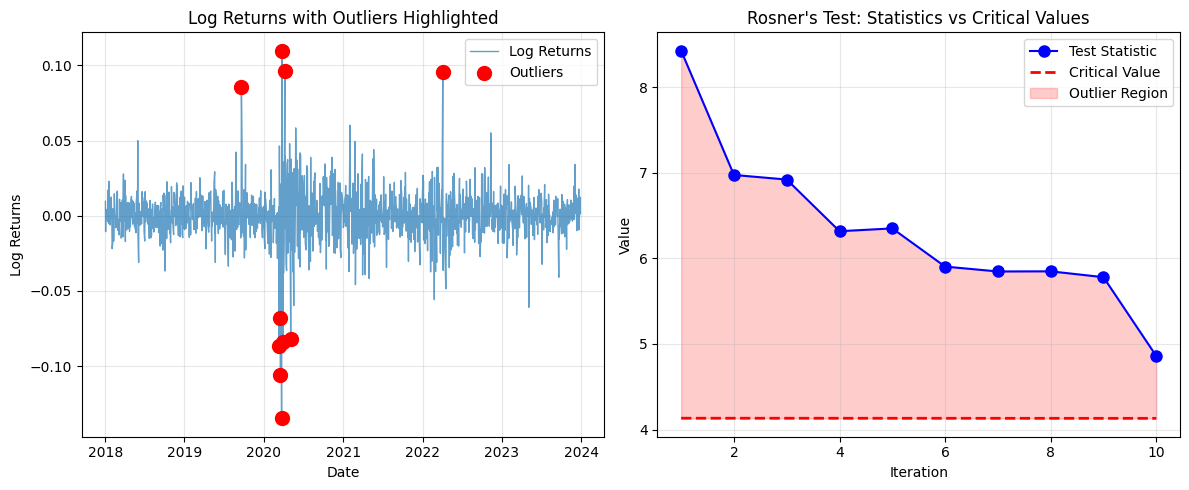


Cleaned 10 outliers through interpolation


In [ ]:
# ============================================================================
# PART 2: OUTLIER DETECTION (ROSNER'S TEST)
# ============================================================================

from scipy import stats

def rosners_test(data, max_outliers=10, alpha=0.05):
    """
    Implement Rosner's Generalized ESD Test for outliers
    """
    data_copy = data.copy()
    outliers = []
    test_stats = []
    critical_vals = []
    outlier_indices = []

    n = len(data_copy)
    for i in range(max_outliers):
        if len(data_copy) <= 3:  # Need at least 3 points for calculation
            break

        # Calculate mean and std
        mean_val = np.mean(data_copy)
        std_val = np.std(data_copy, ddof=1)

        # Calculate absolute deviations from mean
        deviations = np.abs(data_copy - mean_val)

        # Find maximum deviation
        max_dev_idx = np.argmax(deviations)
        max_dev_val = deviations[max_dev_idx]
        test_stat = max_dev_val / std_val
        test_stats.append(test_stat)

        # Calculate critical value
        p = 1 - alpha / (2 * (n - i))
        t_val = stats.t.ppf(p, n - i - 2)
        critical_val = ((n - i - 1) * t_val) / np.sqrt((n - i - 1 + t_val**2) * (n - i + 1))
        critical_vals.append(critical_val)

        # Check if point is outlier
        if test_stat > critical_val:
            outlier_val = data_copy[max_dev_idx]
            outliers.append(outlier_val)
            outlier_indices.append(np.where(data == outlier_val)[0][0])
            # Remove outlier for next iteration
            data_copy = np.delete(data_copy, max_dev_idx)
        else:
            break

    return outliers, test_stats, critical_vals, outlier_indices

# Apply Rosner's test to log returns
log_returns = df['Log_Returns'].values
outliers, test_stats, critical_vals, outlier_indices = rosners_test(log_returns, max_outliers=10, alpha=0.05)

print(f"\n" + "="*50)
print("OUTLIER DETECTION RESULTS (Rosner's Test)")
print("="*50)
print(f"Detected {len(outliers)} outliers in log returns")

for i, (outlier, idx) in enumerate(zip(outliers, outlier_indices)):
    date = df.index[idx]
    print(f"Outlier {i+1}: Value = {outlier:.6f}, Date = {date.date()}")

# Visualize outliers
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df.index, df['Log_Returns'], label='Log Returns', alpha=0.7, linewidth=1)

# Plot outliers
for i, idx in enumerate(outlier_indices):
    plt.scatter(df.index[idx], df.iloc[idx]['Log_Returns'],
                color='red', s=100, zorder=5,
                label='Outliers' if i == 0 else None)

plt.title('Log Returns with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
iterations = range(1, len(test_stats) + 1)
plt.plot(iterations, test_stats, 'bo-', label='Test Statistic', markersize=8)
plt.plot(iterations, critical_vals, 'r--', label='Critical Value', linewidth=2)
plt.fill_between(iterations, critical_vals, test_stats,
                 where=[t > c for t, c in zip(test_stats, critical_vals)],
                 color='red', alpha=0.2, label='Outlier Region')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title("Rosner's Test: Statistics vs Critical Values")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Remove outliers by interpolation
df_clean = df.copy()
if len(outliers) > 0:
    for idx in outlier_indices:
        df_clean.iloc[idx, df_clean.columns.get_loc('Log_Returns')] = np.nan

    # Interpolate missing values
    df_clean['Log_Returns'] = df_clean['Log_Returns'].interpolate(method='linear')

    print(f"\nCleaned {len(outliers)} outliers through interpolation")

# STATIONARITY TESTS


STATIONARITY TESTS

Testing Price Series:
Augmented Dickey-Fuller Test: Price
ADF Statistic: -1.323100
p-value: 0.618539
Number of Lags Used: 8
Number of Observations: 1471
Critical Values:
   1%: -3.435
   5%: -2.864
   10%: -2.568
Result: NON-STATIONARY (p-value >= 0.05)
KPSS Test: Price
KPSS Statistic: 0.165316
p-value: 0.033903
Number of Lags: 25
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216
Result: NON-STATIONARY (p-value < 0.05)

Testing Log Returns Series:
Augmented Dickey-Fuller Test: Log Returns
ADF Statistic: -17.156727
p-value: 0.000000
Number of Lags Used: 5
Number of Observations: 1474
Critical Values:
   1%: -3.435
   5%: -2.864
   10%: -2.568
Result: STATIONARY (p-value < 0.05)
KPSS Test: Log Returns
KPSS Statistic: 0.053168
p-value: 0.100000
Number of Lags: 3
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216
Result: STATIONARY (p-value >= 0.05)

STATIONARITY SUMMARY
        Series  ADF Statistic   ADF p-value  ADF Station

/tmp/ipykernel_4470/4069516501.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='ct', nlags='auto')


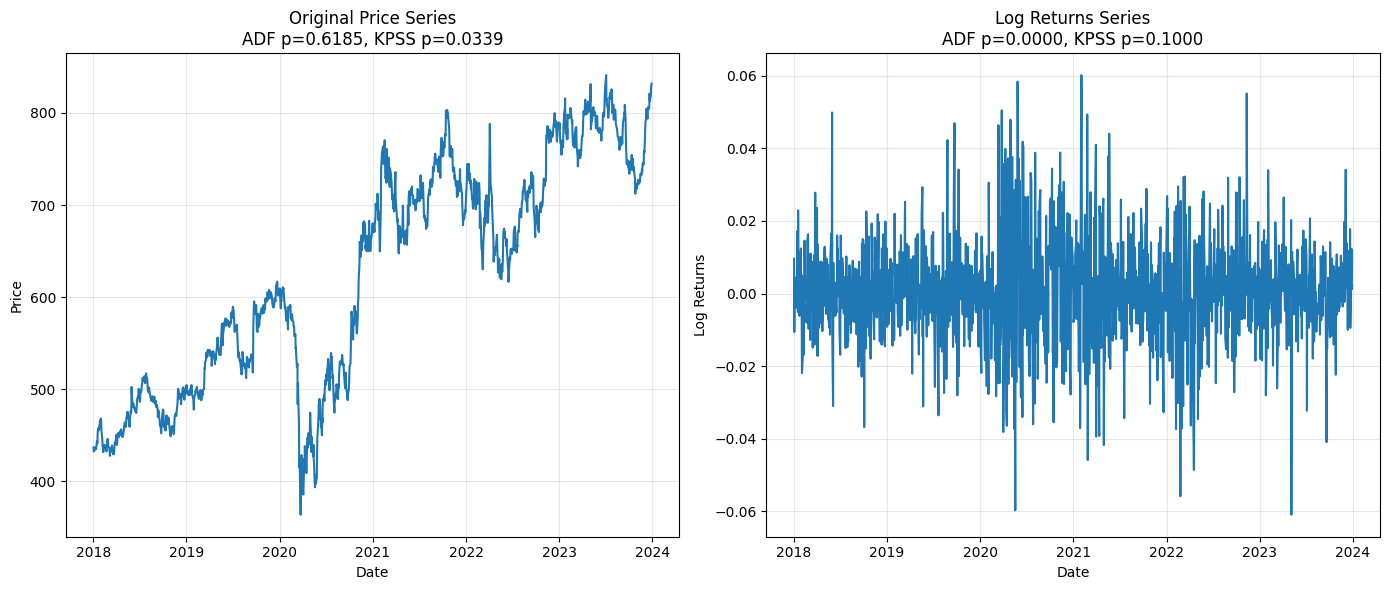

In [ ]:
# ============================================================================
# PART 3: STATIONARITY TESTS
# ============================================================================

from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, signif=0.05, name=""):
    """
    Perform Augmented Dickey-Fuller test
    """
    result = adfuller(series, autolag='AIC')
    print('='*50)
    print(f'Augmented Dickey-Fuller Test: {name}')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Number of Lags Used: {result[2]}')
    print(f'Number of Observations: {result[3]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')

    if result[1] < signif:
        print(f"Result: STATIONARY (p-value < {signif})")
        stationary = True
    else:
        print(f"Result: NON-STATIONARY (p-value >= {signif})")
        stationary = False
    print('='*50)
    return result, stationary

def kpss_test(series, signif=0.05, name=""):
    """
    Perform KPSS test
    """
    result = kpss(series, regression='ct', nlags='auto')
    print('='*50)
    print(f'KPSS Test: {name}')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Number of Lags: {result[2]}')
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'   {key}: {value:.3f}')

    if result[1] < signif:
        print(f"Result: NON-STATIONARY (p-value < {signif})")
        stationary = False
    else:
        print(f"Result: STATIONARY (p-value >= {signif})")
        stationary = True
    print('='*50)
    return result, stationary

# Test stationarity of price and returns
print("\n" + "="*50)
print("STATIONARITY TESTS")
print("="*50)

print("\nTesting Price Series:")
adf_price, adf_price_stat = adf_test(df_clean['Price'], name="Price")
kpss_price, kpss_price_stat = kpss_test(df_clean['Price'], name="Price")

print("\nTesting Log Returns Series:")
adf_returns, adf_returns_stat = adf_test(df_clean['Log_Returns'], name="Log Returns")
kpss_returns, kpss_returns_stat = kpss_test(df_clean['Log_Returns'], name="Log Returns")

# Create summary table
stationarity_summary = pd.DataFrame({
    'Series': ['Price', 'Log Returns'],
    'ADF Statistic': [adf_price[0], adf_returns[0]],
    'ADF p-value': [adf_price[1], adf_returns[1]],
    'ADF Stationary': [adf_price_stat, adf_returns_stat],
    'KPSS Statistic': [kpss_price[0], kpss_returns[0]],
    'KPSS p-value': [kpss_price[1], kpss_returns[1]],
    'KPSS Stationary': [kpss_price_stat, kpss_returns_stat]
})

print("\n" + "="*50)
print("STATIONARITY SUMMARY")
print("="*50)
print(stationarity_summary)

# Visualize stationarity
plt.figure(figsize=(14, 6))

# Plot 1: Original price series
plt.subplot(1, 2, 1)
plt.plot(df_clean.index, df_clean['Price'])
plt.title(f'Original Price Series\nADF p={adf_price[1]:.4f}, KPSS p={kpss_price[1]:.4f}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)

# Plot 2: Log returns (stationary)
plt.subplot(1, 2, 2)
plt.plot(df_clean.index, df_clean['Log_Returns'])
plt.title(f'Log Returns Series\nADF p={adf_returns[1]:.4f}, KPSS p={kpss_returns[1]:.4f}')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# DATA PREPROCESSING FOR MODELS

In [ ]:
# ============================================================================
# PART 4: DATA PREPROCESSING FOR MODELS
# ============================================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

def prepare_lstm_data(data, sequence_length=60, train_ratio=0.8):
    """
    Prepare data for LSTM model
    """
    # Use price data
    prices = data['Price'].values.reshape(-1, 1)

    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(prices)

    # Create sequences for LSTM
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i, 0])
        y.append(scaled_data[i, 0])

    X, y = np.array(X), np.array(y)

    # Reshape for LSTM [samples, timesteps, features]
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Split into train and test sets
    train_size = int(len(X) * train_ratio)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print(f"\nLSTM Data Preparation:")
    print(f"Original data shape: {prices.shape}")
    print(f"Sequence length: {sequence_length}")
    print(f"Total sequences: {len(X)}")
    print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test shape: X={X_test.shape}, y={y_test.shape}")

    return X_train, X_test, y_train, y_test, scaler

def prepare_nbeats_data(data, forecast_horizon=30, train_ratio=0.8):
    """
    Prepare data for N-BEATS model using Darts
    """
    from darts import TimeSeries

    # Create a copy of the data with proper date range
    df_nbeats = data.copy()

    # Create a complete date range (business days only)
    date_range = pd.date_range(start=df_nbeats.index.min(),
                               end=df_nbeats.index.max(),
                               freq='B')  # Business days

    # Reindex to fill missing dates
    df_nbeats = df_nbeats.reindex(date_range)

    # Forward fill missing values (for weekends/holidays)
    df_nbeats['Price'] = df_nbeats['Price'].ffill()
    df_nbeats['Returns'] = df_nbeats['Price'].pct_change()
    df_nbeats['Log_Returns'] = np.log(df_nbeats['Price'] / df_nbeats['Price'].shift(1))

    # Drop any remaining NaN values
    df_nbeats = df_nbeats.dropna()

    # Create TimeSeries object with explicit frequency
    series = TimeSeries.from_dataframe(
        df_nbeats[['Price']].reset_index(),
        time_col='index',
        value_cols=['Price'],
        fill_missing_dates=True,
        freq='B'  # Business day frequency
    )

    # Split train-test
    train_size = int(len(series) * train_ratio)
    train_series = series[:train_size]
    test_series = series[train_size:]

    print(f"\nN-BEATS Data Preparation:")
    print(f"Original data points: {len(data)}")
    print(f"After filling dates: {len(df_nbeats)}")
    print(f"Full series length: {len(series)}")
    print(f"Train series length: {len(train_series)}")
    print(f"Test series length: {len(test_series)}")
    print(f"Forecast horizon: {forecast_horizon}")
    print(f"Series frequency: {series.freq}")

    # Show some sample dates
    print(f"\nSample dates in series:")
    print(f"Start: {series.start_time()}")
    print(f"End: {series.end_time()}")
    print(f"Train end: {train_series.end_time()}")
    print(f"Test start: {test_series.start_time()}")

    return train_series, test_series, series, df_nbeats

# Prepare data for both models
sequence_length = 60
forecast_horizon = 30

print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# For LSTM
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler = prepare_lstm_data(
    df_clean, sequence_length=sequence_length, train_ratio=0.8
)

# For N-BEATS
train_series, test_series, full_series, df_nbeats = prepare_nbeats_data(df_clean, forecast_horizon)


DATA PREPROCESSING

LSTM Data Preparation:
Original data shape: (1480, 1)
Sequence length: 60
Total sequences: 1420
Train shape: X=(1136, 60, 1), y=(1136,)
Test shape: X=(284, 60, 1), y=(284,)

N-BEATS Data Preparation:
Original data points: 1480
After filling dates: 1563
Full series length: 1563
Train series length: 1250
Test series length: 313
Forecast horizon: 30
Series frequency: <BusinessDay>

Sample dates in series:
Start: 2018-01-03 00:00:00
End: 2023-12-29 00:00:00
Train end: 2022-10-18 00:00:00
Test start: 2022-10-19 00:00:00


# LSTM MODEL IMPLEMENTATION


TRAINING LSTM MODEL

LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

...


Epoch 1: finished saving model to best_lstm_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0184 - mae: 0.1077 - val_loss: 0.0094 - val_mae: 0.0896 - learning_rate: 0.0010
Epoch 2/100
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0076 - mae: 0.0685
Epoch 2: val_loss improved from 0.00943 to 0.00231, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0113 - mae: 0.0823 - val_loss: 0.0023 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 3/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - mae: 0.0572
Epoch 3: val_loss did not improve from 0.00231
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0089 - mae: 0.0723 - val_loss: 0.0041 - val_mae: 0.0552 - learning_rate: 0.0010
Epoch 4/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0039 - mae: 0.0451
Epoch 4: val_loss improved from 0.00231 to 0.00117, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0084 - mae: 0.0678 - val_loss: 0.0012 - val_mae: 0.0264 - learning_rate: 0.0010
Epoch 5/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0056 - mae: 0.0606
Epoch 5: val_loss did not improve from 0.00117
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081 - mae: 0.0684 - val_loss: 0.0041 - val_mae: 0.0565 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034 - mae: 0.0427
Epoch 6: val_loss did not improve from 0.00117
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0066 - mae: 0.0612 - val_loss: 0.0037 - val_mae: 0.0527 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034 - mae: 0.0437
Epoch 7: val_loss did not improve from 0.00117
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0061 - mae: 0.0592 - val_loss: 0.0023 - val_mae: 0.0402 - learning_rate: 0.0010
Epoch 8/100
33/36 ━━━━━━━━━━━━━━━━━━━━ 0s 14


Epoch 12: finished saving model to best_lstm_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - mae: 0.0489 - val_loss: 0.0010 - val_mae: 0.0251 - learning_rate: 0.0010
Epoch 13/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - mae: 0.0374
Epoch 13: val_loss did not improve from 0.00105
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0514 - val_loss: 0.0037 - val_mae: 0.0547 - learning_rate: 0.0010
Epoch 14/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - mae: 0.0337
Epoch 14: val_loss did not improve from 0.00105
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045 - mae: 0.0490 - val_loss: 0.0027 - val_mae: 0.0452 - learning_rate: 0.0010
Epoch 15/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - mae: 0.0364
Epoch 15: val_loss did not improve from 0.00105
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0045 - mae: 0.0495 - val_loss: 0.0050 - val_mae: 0.0655 - learning_rate: 0.0010
Epoch 16/100
31/36 ━━━━━━━━━━━━━━━━━━


Epoch 16: finished saving model to best_lstm_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041 - mae: 0.0466 - val_loss: 8.0299e-04 - val_mae: 0.0219 - learning_rate: 0.0010
Epoch 17/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0452
Epoch 17: val_loss did not improve from 0.00080
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - mae: 0.0531 - val_loss: 0.0018 - val_mae: 0.0355 - learning_rate: 0.0010
Epoch 18/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0021 - mae: 0.0337
Epoch 18: val_loss did not improve from 0.00080
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0040 - mae: 0.0475 - val_loss: 0.0031 - val_mae: 0.0490 - learning_rate: 0.0010
Epoch 19/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - mae: 0.0267
Epoch 19: val_loss did not improve from 0.00080
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037 - mae: 0.0439 - val_loss: 0.0012 - val_mae: 0.0273 - learning_rate: 0.0010
Epoch 20/100
35/36 ━━━━━━━━━━━━━━

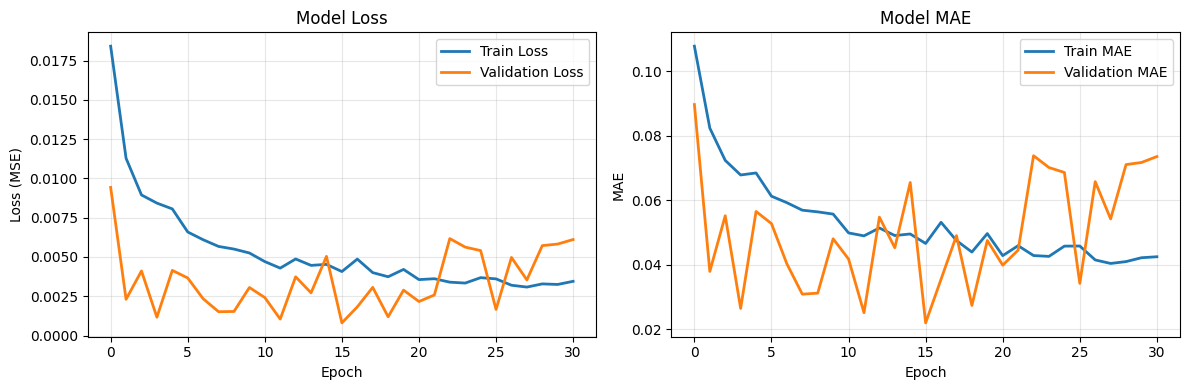


Making LSTM predictions...
Predictions shape: (284,)
Actual values shape: (284,)


In [ ]:
# ============================================================================
# PART 5: LSTM MODEL IMPLEMENTATION
# ============================================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def build_lstm_model(input_shape, units=100):
    """
    Build LSTM model architecture
    """
    model = Sequential([
        # First LSTM layer
        LSTM(units=units, return_sequences=True, input_shape=input_shape,
             kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        Dropout(0.2),

        # Second LSTM layer
        LSTM(units=50, return_sequences=False,
             kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal'),
        Dropout(0.2),

        # Dense layers
        Dense(25, activation='relu', kernel_initializer='he_normal'),
        Dropout(0.1),

        # Output layer
        Dense(1, activation='linear')
    ])

    # Compile model
    optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    print("\nLSTM Model Architecture:")
    model.summary()

    return model

def train_lstm_model(X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    """
    Train LSTM model
    """
    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_lstm_model(input_shape)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001, verbose=1),
        ModelCheckpoint('best_lstm_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
    ]

    print("\nTraining LSTM Model...")
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Important for time series
    )

    return model, history

# Train LSTM model
print("\n" + "="*50)
print("TRAINING LSTM MODEL")
print("="*50)

lstm_model, lstm_history = train_lstm_model(
    X_train_lstm, y_train_lstm, X_test_lstm, y_test_lstm,
    epochs=100, batch_size=32
)

# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Model MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\nTraining History:")
plot_training_history(lstm_history)

# Make predictions with LSTM
def lstm_predict(model, X_test, scaler, original_data, sequence_length):
    """
    Make predictions with LSTM model
    """
    # Make predictions
    print("\nMaking LSTM predictions...")
    predictions_scaled = model.predict(X_test, verbose=0)

    # Reshape for inverse transform
    predictions_scaled_reshaped = predictions_scaled.reshape(-1, 1)

    # Create dummy array for inverse transform
    dummy_array = np.zeros((len(predictions_scaled_reshaped), 1))
    dummy_array[:, 0] = predictions_scaled_reshaped[:, 0]

    # Inverse transform to get actual prices
    predictions = scaler.inverse_transform(dummy_array)[:, 0]

    # Get actual values (inverse transform)
    actual_scaled_reshaped = np.zeros((len(y_test_lstm), 1))
    actual_scaled_reshaped[:, 0] = y_test_lstm
    actual = scaler.inverse_transform(actual_scaled_reshaped)[:, 0]

    # Create date index for predictions
    pred_dates = original_data.index[-len(predictions):]

    print(f"Predictions shape: {predictions.shape}")
    print(f"Actual values shape: {actual.shape}")

    return predictions, actual, pred_dates

lstm_predictions, lstm_actual, lstm_dates = lstm_predict(
    lstm_model, X_test_lstm, scaler, df_clean, sequence_length
)

# SEASONALITY ANALYSIS WITH KRUSKAL-WALLIS TEST


SEASONALITY ANALYSIS USING KRUSKAL-WALLIS NON-PARAMETRIC TEST

Dataset Features Added:
- Year (range: 2018 to 2023)
- Month (1-12)
- Day of Week (0=Monday, 6=Sunday)
- Week of Year (1-52)
- Quarter (1-4)

1. MONTHLY SEASONALITY TEST (KRUSKAL-WALLIS)
Month January  : 128 observations | Mean: -0.000102 | Std: 0.011496
Month February : 117 observations | Mean: -0.000283 | Std: 0.016508
Month March    : 121 observations | Mean: -0.001273 | Std: 0.026742
Month April    : 113 observations | Mean: 0.001285 | Std: 0.021955
Month May      : 126 observations | Mean: 0.001350 | Std: 0.019265
Month June     : 127 observations | Mean: 0.001099 | Std: 0.012462
Month July     : 131 observations | Mean: -0.000663 | Std: 0.012468
Month August   : 125 observations | Mean: 0.000889 | Std: 0.011904
Month September: 122 observations | Mean: -0.000133 | Std: 0.014712
Month October  : 121 observations | Mean: 0.000580 | Std: 0.014208
Month November : 121 observations | Mean: 0.003452 | Std: 0.012319
Month D

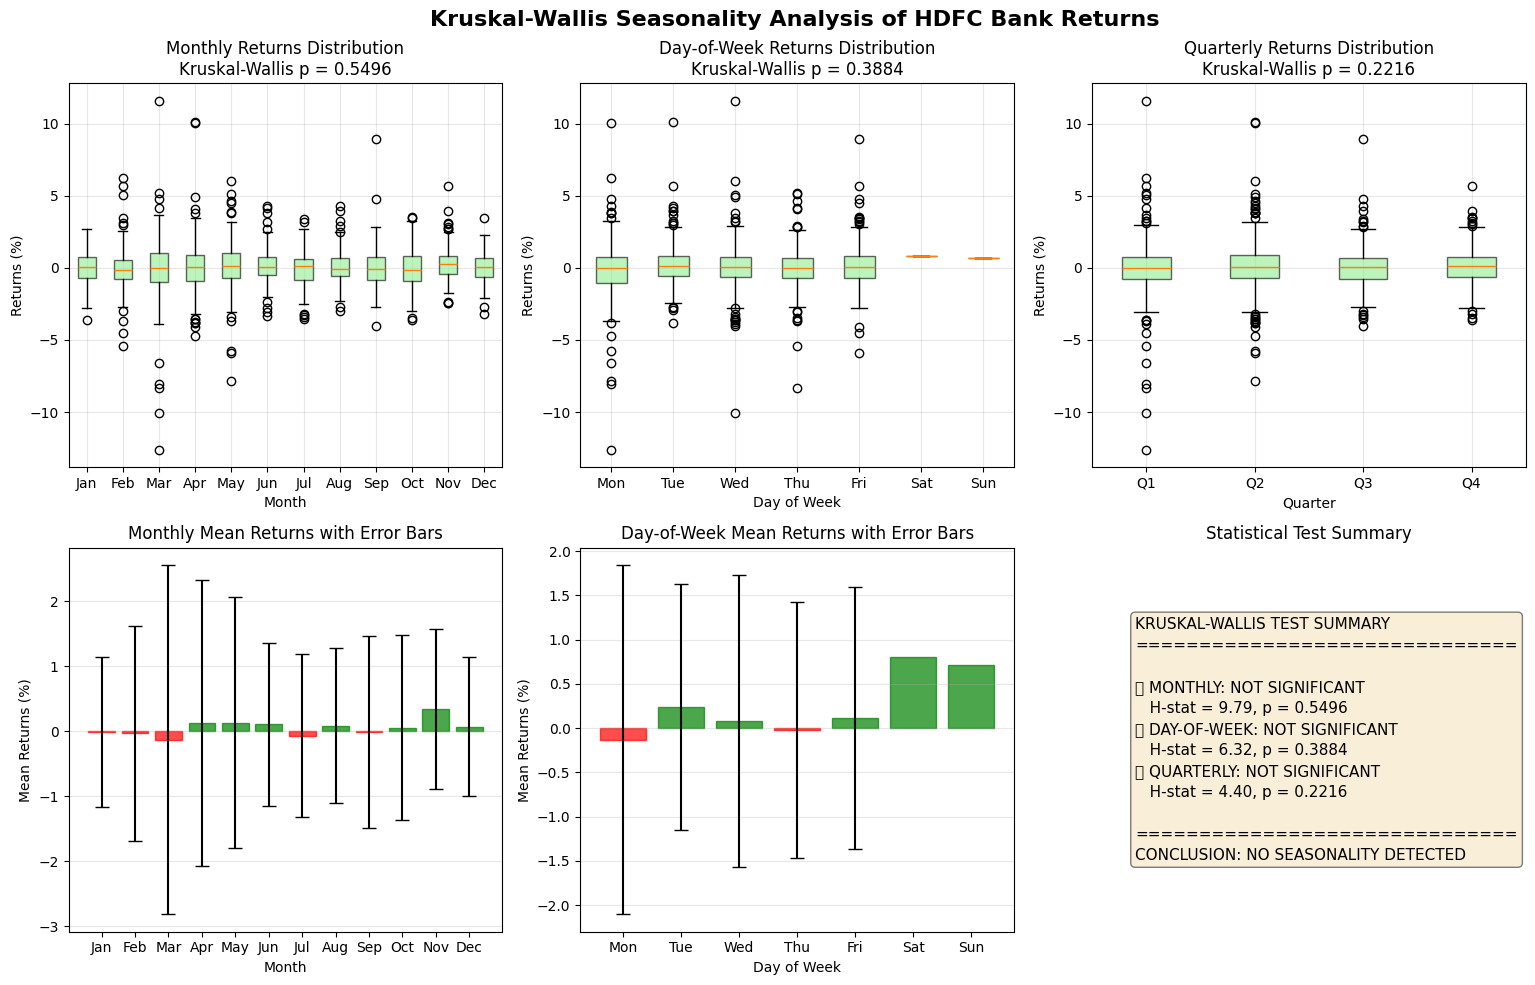


5. ADDITIONAL NON-PARAMETRIC ANALYSES

Friedman Test (Monthly Returns by Year):
Chi-square statistic: 1.1905
p-value: 0.945788
→ FAIL TO REJECT H₀: No significant yearly pattern in monthly returns

Kendall's W Test (Consistency across years):
Kendall's W Coefficient: 0.0894
Interpretation: Weak agreement across years
Number of years compared: 3
Number of months compared: 12

FINAL SEASONALITY ASSESSMENT USING NON-PARAMETRIC TESTS

TEST RESULTS SUMMARY:
----------------------------------------
MONTHLY   : ✗ NOT SIGNIFICANT    (p = 0.549615)
DAILY     : ✗ NOT SIGNIFICANT    (p = 0.388363)
QUARTERLY : ✗ NOT SIGNIFICANT    (p = 0.221624)

OVERALL: NO STRONG SEASONALITY EVIDENCE

RECOMMENDATIONS:
1. Standard ARIMA/LSTM models are sufficient
2. Focus on trend and residual components
3. Consider other factors (market conditions, news)

SEASONALITY ANALYSIS COMPLETED


In [ ]:
# ============================================================================
# PART 6: SEASONALITY ANALYSIS WITH KRUSKAL-WALLIS TEST
# ============================================================================

from scipy import stats
import calendar

print("\n" + "="*70)
print("SEASONALITY ANALYSIS USING KRUSKAL-WALLIS NON-PARAMETRIC TEST")
print("="*70)

# Add date features for analysis
df_seasonality = df_clean.copy()
df_seasonality['Year'] = df_seasonality.index.year
df_seasonality['Month'] = df_seasonality.index.month
df_seasonality['DayOfWeek'] = df_seasonality.index.dayofweek  # Monday=0, Sunday=6
df_seasonality['WeekOfYear'] = df_seasonality.index.isocalendar().week
df_seasonality['Quarter'] = df_seasonality.index.quarter

print("\nDataset Features Added:")
print(f"- Year (range: {df_seasonality['Year'].min()} to {df_seasonality['Year'].max()})")
print(f"- Month (1-12)")
print(f"- Day of Week (0=Monday, 6=Sunday)")
print(f"- Week of Year (1-52)")
print(f"- Quarter (1-4)")

# 1. KRUSKAL-WALLIS TEST FOR MONTHLY SEASONALITY
print("\n" + "="*50)
print("1. MONTHLY SEASONALITY TEST (KRUSKAL-WALLIS)")
print("="*50)

# Prepare monthly groups for Kruskal-Wallis test
monthly_groups = []
monthly_data = {}

for month in range(1, 13):
    month_name = calendar.month_name[month]
    month_returns = df_seasonality[df_seasonality['Month'] == month]['Returns'].dropna().values

    if len(month_returns) > 0:
        monthly_groups.append(month_returns)
        monthly_data[month_name] = month_returns
        print(f"Month {month_name:9s}: {len(month_returns):3d} observations | "
              f"Mean: {np.mean(month_returns):.6f} | "
              f"Std: {np.std(month_returns):.6f}")

# Perform Kruskal-Wallis test
if len(monthly_groups) >= 2:
    h_stat, p_value = stats.kruskal(*monthly_groups)

    print(f"\nKruskal-Wallis Test Results:")
    print(f"H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Degrees of freedom: {len(monthly_groups)-1}")

    if p_value < 0.05:
        print("\n→ REJECT NULL HYPOTHESIS (H₀)")
        print("  There is SIGNIFICANT monthly seasonality in returns")
        print("  At least one month has different returns distribution")

        # Post-hoc Dunn's test to identify which months are different
        print("\n" + "-"*50)
        print("POST-HOC ANALYSIS (Pairwise Comparisons)")

        # Manual pairwise comparisons using Mann-Whitney U test
        months = list(monthly_data.keys())
        significant_pairs = []

        for i in range(len(months)):
            for j in range(i+1, len(months)):
                if len(monthly_data[months[i]]) > 0 and len(monthly_data[months[j]]) > 0:
                    u_stat, p_val_pair = stats.mannwhitneyu(
                        monthly_data[months[i]],
                        monthly_data[months[j]],
                        alternative='two-sided'
                    )

                    if p_val_pair < 0.05:
                        significant_pairs.append((months[i], months[j], p_val_pair))

        if significant_pairs:
            print("\nSignificant pairwise differences (p < 0.05):")
            for month1, month2, p_val in significant_pairs[:10]:  # Show first 10
                print(f"  {month1} vs {month2}: p = {p_val:.6f}")
        else:
            print("\nNo significant pairwise differences found")

    else:
        print("\n→ FAIL TO REJECT NULL HYPOTHESIS (H₀)")
        print("  NO significant monthly seasonality detected")
        print("  Returns distributions across months are similar")

else:
    print("\nInsufficient data for Kruskal-Wallis test")

# 2. KRUSKAL-WALLIS TEST FOR DAY-OF-WEEK SEASONALITY
print("\n" + "="*50)
print("2. DAY-OF-WEEK SEASONALITY TEST (KRUSKAL-WALLIS)")
print("="*50)

# Prepare day-of-week groups
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_groups = []
dow_data = {}

for dow in range(7):
    dow_returns = df_seasonality[df_seasonality['DayOfWeek'] == dow]['Returns'].dropna().values

    if len(dow_returns) > 0:
        dow_groups.append(dow_returns)
        dow_data[day_names[dow]] = dow_returns
        print(f"Day {day_names[dow]:12s}: {len(dow_returns):3d} observations | "
              f"Mean: {np.mean(dow_returns):.6f} | "
              f"Std: {np.std(dow_returns):.6f}")

# Perform Kruskal-Wallis test
if len(dow_groups) >= 2:
    h_stat_dow, p_value_dow = stats.kruskal(*dow_groups)

    print(f"\nKruskal-Wallis Test Results:")
    print(f"H-statistic: {h_stat_dow:.4f}")
    print(f"p-value: {p_value_dow:.6f}")

    if p_value_dow < 0.05:
        print("\n→ REJECT NULL HYPOTHESIS (H₀)")
        print("  There is SIGNIFICANT day-of-week effect in returns")

        # Find best and worst performing days
        print("\nDay Performance Ranking (by median returns):")
        day_medians = {}
        for day_name, returns in dow_data.items():
            if len(returns) > 0:
                day_medians[day_name] = np.median(returns)

        # Sort days by median returns
        sorted_days = sorted(day_medians.items(), key=lambda x: x[1], reverse=True)

        for rank, (day_name, median_return) in enumerate(sorted_days, 1):
            print(f"  {rank}. {day_name:12s}: Median Return = {median_return:.6f}")

    else:
        print("\n→ FAIL TO REJECT NULL HYPOTHESIS (H₀)")
        print("  NO significant day-of-week effect detected")

else:
    print("\nInsufficient data for day-of-week analysis")

# 3. KRUSKAL-WALLIS TEST FOR QUARTERLY SEASONALITY
print("\n" + "="*50)
print("3. QUARTERLY SEASONALITY TEST (KRUSKAL-WALLIS)")
print("="*50)

# Prepare quarterly groups
quarter_groups = []
quarter_data = {}

for quarter in range(1, 5):
    quarter_returns = df_seasonality[df_seasonality['Quarter'] == quarter]['Returns'].dropna().values

    if len(quarter_returns) > 0:
        quarter_groups.append(quarter_returns)
        quarter_data[f'Q{quarter}'] = quarter_returns
        print(f"Quarter Q{quarter}: {len(quarter_returns):3d} observations | "
              f"Mean: {np.mean(quarter_returns):.6f} | "
              f"Std: {np.std(quarter_returns):.6f}")

# Perform Kruskal-Wallis test
if len(quarter_groups) >= 2:
    h_stat_q, p_value_q = stats.kruskal(*quarter_groups)

    print(f"\nKruskal-Wallis Test Results:")
    print(f"H-statistic: {h_stat_q:.4f}")
    print(f"p-value: {p_value_q:.6f}")

    if p_value_q < 0.05:
        print("\n→ REJECT NULL HYPOTHESIS (H₀)")
        print("  There is SIGNIFICANT quarterly seasonality in returns")
    else:
        print("\n→ FAIL TO REJECT NULL HYPOTHESIS (H₀)")
        print("  NO significant quarterly seasonality detected")

else:
    print("\nInsufficient data for quarterly analysis")

# 4. VISUALIZATION OF SEASONALITY RESULTS
print("\n" + "="*50)
print("4. VISUALIZATION OF SEASONALITY PATTERNS")
print("="*50)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Kruskal-Wallis Seasonality Analysis of HDFC Bank Returns',
             fontsize=16, fontweight='bold')

# 4.1 Monthly Returns Box Plot
month_names = [calendar.month_abbr[i] for i in range(1, 13)]
monthly_returns_data = []

for month in range(1, 13):
    month_returns = df_seasonality[df_seasonality['Month'] == month]['Returns'].dropna().values * 100
    if len(month_returns) > 0:
        monthly_returns_data.append(month_returns)

bp1 = axes[0, 0].boxplot(monthly_returns_data, patch_artist=True)
axes[0, 0].set_title(f'Monthly Returns Distribution\nKruskal-Wallis p = {p_value:.4f}', fontsize=12)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Returns (%)')
axes[0, 0].set_xticklabels(month_names)
axes[0, 0].grid(True, alpha=0.3)

# Color boxes based on significance
if p_value < 0.05:
    for patch in bp1['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.6)
else:
    for patch in bp1['boxes']:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.6)

# 4.2 Day-of-Week Returns Box Plot
dow_returns_data = []
available_days = []

for dow in range(7):
    dow_returns = df_seasonality[df_seasonality['DayOfWeek'] == dow]['Returns'].dropna().values * 100
    if len(dow_returns) > 0:
        dow_returns_data.append(dow_returns)
        available_days.append(day_names[dow])

bp2 = axes[0, 1].boxplot(dow_returns_data, patch_artist=True)
axes[0, 1].set_title(f'Day-of-Week Returns Distribution\nKruskal-Wallis p = {p_value_dow:.4f}', fontsize=12)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Returns (%)')
axes[0, 1].set_xticklabels([d[:3] for d in available_days])
axes[0, 1].grid(True, alpha=0.3)

if p_value_dow < 0.05:
    for patch in bp2['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.6)
else:
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.6)

# 4.3 Quarterly Returns Box Plot
quarter_returns_data = []
for quarter in range(1, 5):
    q_returns = df_seasonality[df_seasonality['Quarter'] == quarter]['Returns'].dropna().values * 100
    if len(q_returns) > 0:
        quarter_returns_data.append(q_returns)

bp3 = axes[0, 2].boxplot(quarter_returns_data, patch_artist=True)
axes[0, 2].set_title(f'Quarterly Returns Distribution\nKruskal-Wallis p = {p_value_q:.4f}', fontsize=12)
axes[0, 2].set_xlabel('Quarter')
axes[0, 2].set_ylabel('Returns (%)')
axes[0, 2].set_xticklabels([f'Q{i}' for i in range(1, len(quarter_returns_data)+1)])
axes[0, 2].grid(True, alpha=0.3)

if p_value_q < 0.05:
    for patch in bp3['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.6)
else:
    for patch in bp3['boxes']:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.6)

# 4.4 Monthly Mean Returns Bar Plot
monthly_mean_returns = []
monthly_std_returns = []

for month in range(1, 13):
    month_data = df_seasonality[df_seasonality['Month'] == month]['Returns'].dropna()
    if len(month_data) > 0:
        monthly_mean_returns.append(month_data.mean() * 100)
        monthly_std_returns.append(month_data.std() * 100)
    else:
        monthly_mean_returns.append(0)
        monthly_std_returns.append(0)

x_pos = np.arange(12)
bars = axes[1, 0].bar(x_pos, monthly_mean_returns, yerr=monthly_std_returns,
                      capsize=5, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Monthly Mean Returns with Error Bars', fontsize=12)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Mean Returns (%)')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(month_names)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Color bars based on sign
for bar, mean_return in zip(bars, monthly_mean_returns):
    if mean_return > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

# 4.5 Day-of-Week Mean Returns Bar Plot
dow_mean_returns = []
dow_std_returns = []

for dow in range(7):
    if dow < len(available_days):  # Only for available days
        dow_data = df_seasonality[df_seasonality['DayOfWeek'] == dow]['Returns'].dropna()
        if len(dow_data) > 0:
            dow_mean_returns.append(dow_data.mean() * 100)
            dow_std_returns.append(dow_data.std() * 100)
        else:
            dow_mean_returns.append(0)
            dow_std_returns.append(0)

x_pos_dow = np.arange(len(available_days))
bars_dow = axes[1, 1].bar(x_pos_dow, dow_mean_returns, yerr=dow_std_returns,
                         capsize=5, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Day-of-Week Mean Returns with Error Bars', fontsize=12)
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Mean Returns (%)')
axes[1, 1].set_xticks(x_pos_dow)
axes[1, 1].set_xticklabels([d[:3] for d in available_days])
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, mean_return in zip(bars_dow, dow_mean_returns):
    if mean_return > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

# 4.6 Summary Text
summary_text = "KRUSKAL-WALLIS TEST SUMMARY\n"
summary_text += "="*30 + "\n\n"

# Monthly results
if 'p_value' in locals():
    if p_value < 0.05:
        summary_text += "📈 MONTHLY: SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat:.2f}, p = {p_value:.4f}\n"
    else:
        summary_text += "📊 MONTHLY: NOT SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat:.2f}, p = {p_value:.4f}\n"

# Day-of-week results
if 'p_value_dow' in locals():
    if p_value_dow < 0.05:
        summary_text += "📈 DAY-OF-WEEK: SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat_dow:.2f}, p = {p_value_dow:.4f}\n"
    else:
        summary_text += "📊 DAY-OF-WEEK: NOT SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat_dow:.2f}, p = {p_value_dow:.4f}\n"

# Quarterly results
if 'p_value_q' in locals():
    if p_value_q < 0.05:
        summary_text += "📈 QUARTERLY: SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat_q:.2f}, p = {p_value_q:.4f}\n"
    else:
        summary_text += "📊 QUARTERLY: NOT SIGNIFICANT\n"
        summary_text += f"   H-stat = {h_stat_q:.2f}, p = {p_value_q:.4f}\n"

summary_text += "\n" + "="*30 + "\n"
if (p_value < 0.05 or p_value_dow < 0.05 or p_value_q < 0.05):
    summary_text += "CONCLUSION: SEASONALITY DETECTED"
else:
    summary_text += "CONCLUSION: NO SEASONALITY DETECTED"

axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11,
                verticalalignment='center', linespacing=1.5,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 2].set_title('Statistical Test Summary', fontsize=12)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 5. ADDITIONAL NON-PARAMETRIC TESTS
print("\n" + "="*50)
print("5. ADDITIONAL NON-PARAMETRIC ANALYSES")
print("="*50)

# 5.1 Friedman Test (non-parametric alternative to repeated measures ANOVA)
print("\nFriedman Test (Monthly Returns by Year):")
# Create a matrix of monthly returns by year
years = sorted(df_seasonality['Year'].unique())
monthly_by_year = []

for month in range(1, 13):
    month_returns_by_year = []
    for year in years:
        year_month_data = df_seasonality[(df_seasonality['Year'] == year) &
                                        (df_seasonality['Month'] == month)]['Returns'].dropna()
        if len(year_month_data) > 0:
            month_returns_by_year.append(np.mean(year_month_data))
        else:
            month_returns_by_year.append(np.nan)

    # Remove years with NaN for this month
    valid_returns = [val for val in month_returns_by_year if not np.isnan(val)]
    if len(valid_returns) >= 2:
        monthly_by_year.append(valid_returns)

# Perform Friedman test if we have enough data
if len(monthly_by_year) >= 3 and all(len(row) >= 3 for row in monthly_by_year):
    try:
        # Transpose the matrix for Friedman test
        friedman_data = np.array(monthly_by_year).T

        if friedman_data.shape[0] >= 2 and friedman_data.shape[1] >= 3:
            chi2_stat, p_value_friedman = stats.friedmanchisquare(*friedman_data)

            print(f"Chi-square statistic: {chi2_stat:.4f}")
            print(f"p-value: {p_value_friedman:.6f}")

            if p_value_friedman < 0.05:
                print("→ REJECT H₀: Significant differences across years for same months")
            else:
                print("→ FAIL TO REJECT H₀: No significant yearly pattern in monthly returns")
    except:
        print("Could not perform Friedman test due to data constraints")
else:
    print("Insufficient data for Friedman test")

# 5.2 Kendall's W Test of Concordance
print("\nKendall's W Test (Consistency across years):")
# Check if returns patterns are consistent across years
yearly_ranks = []

for year in years[-3:]:  # Last 3 years for comparison
    yearly_data = df_seasonality[df_seasonality['Year'] == year]

    # Get monthly mean returns for this year
    monthly_means = []
    for month in range(1, 13):
        month_mean = yearly_data[yearly_data['Month'] == month]['Returns'].mean()
        if not np.isnan(month_mean):
            monthly_means.append(month_mean)

    if len(monthly_means) >= 3:
        # Rank the monthly means
        ranks = stats.rankdata(monthly_means)
        yearly_ranks.append(ranks)

if len(yearly_ranks) >= 3:
    # Calculate Kendall's W
    yearly_ranks_array = np.array(yearly_ranks)
    n = yearly_ranks_array.shape[1]  # number of months
    m = yearly_ranks_array.shape[0]  # number of years

    # Sum of ranks for each month
    R = np.sum(yearly_ranks_array, axis=0)

    # Mean of R
    R_mean = np.mean(R)

    # Sum of squared deviations
    S = np.sum((R - R_mean)**2)

    # Kendall's W
    W = (12 * S) / (m**2 * (n**3 - n))

    print(f"Kendall's W Coefficient: {W:.4f}")
    print(f"Interpretation: {'Strong agreement' if W > 0.7 else 'Moderate agreement' if W > 0.3 else 'Weak agreement'} across years")
    print(f"Number of years compared: {m}")
    print(f"Number of months compared: {n}")
else:
    print("Insufficient data for Kendall's W test")

# 6. FINAL SEASONALITY ASSESSMENT
print("\n" + "="*70)
print("FINAL SEASONALITY ASSESSMENT USING NON-PARAMETRIC TESTS")
print("="*70)

# Create assessment summary
seasonality_assessment = {
    'monthly': {'significant': p_value < 0.05 if 'p_value' in locals() else False,
                'test': 'Kruskal-Wallis',
                'p_value': p_value if 'p_value' in locals() else np.nan},
    'daily': {'significant': p_value_dow < 0.05 if 'p_value_dow' in locals() else False,
              'test': 'Kruskal-Wallis',
              'p_value': p_value_dow if 'p_value_dow' in locals() else np.nan},
    'quarterly': {'significant': p_value_q < 0.05 if 'p_value_q' in locals() else False,
                  'test': 'Kruskal-Wallis',
                  'p_value': p_value_q if 'p_value_q' in locals() else np.nan}
}

# Determine overall seasonality
significant_tests = sum([assessment['significant']
                        for assessment in seasonality_assessment.values()])

print("\nTEST RESULTS SUMMARY:")
print("-"*40)
for period, results in seasonality_assessment.items():
    status = "✓ SIGNIFICANT" if results['significant'] else "✗ NOT SIGNIFICANT"
    print(f"{period.upper():10s}: {status:20s} (p = {results['p_value']:.6f})")

print("\n" + "="*40)
if significant_tests > 0:
    print(f"OVERALL: SEASONALITY DETECTED ({significant_tests}/3 tests significant)")
    print("\nRECOMMENDATIONS:")
    print("1. Consider seasonal models (SARIMA, Seasonal LSTM)")
    print("2. Include seasonal dummy variables in models")
    print("3. Account for calendar effects in forecasting")
else:
    print("OVERALL: NO STRONG SEASONALITY EVIDENCE")
    print("\nRECOMMENDATIONS:")
    print("1. Standard ARIMA/LSTM models are sufficient")
    print("2. Focus on trend and residual components")
    print("3. Consider other factors (market conditions, news)")

print("\n" + "="*70)
print("SEASONALITY ANALYSIS COMPLETED")
print("="*70)

# SARIMA MODEL (Seasonal ARIMA)


PART 7: SARIMA MODEL WITH SEASONALITY

1. SEASONAL DECOMPOSITION
--------------------------------------------------


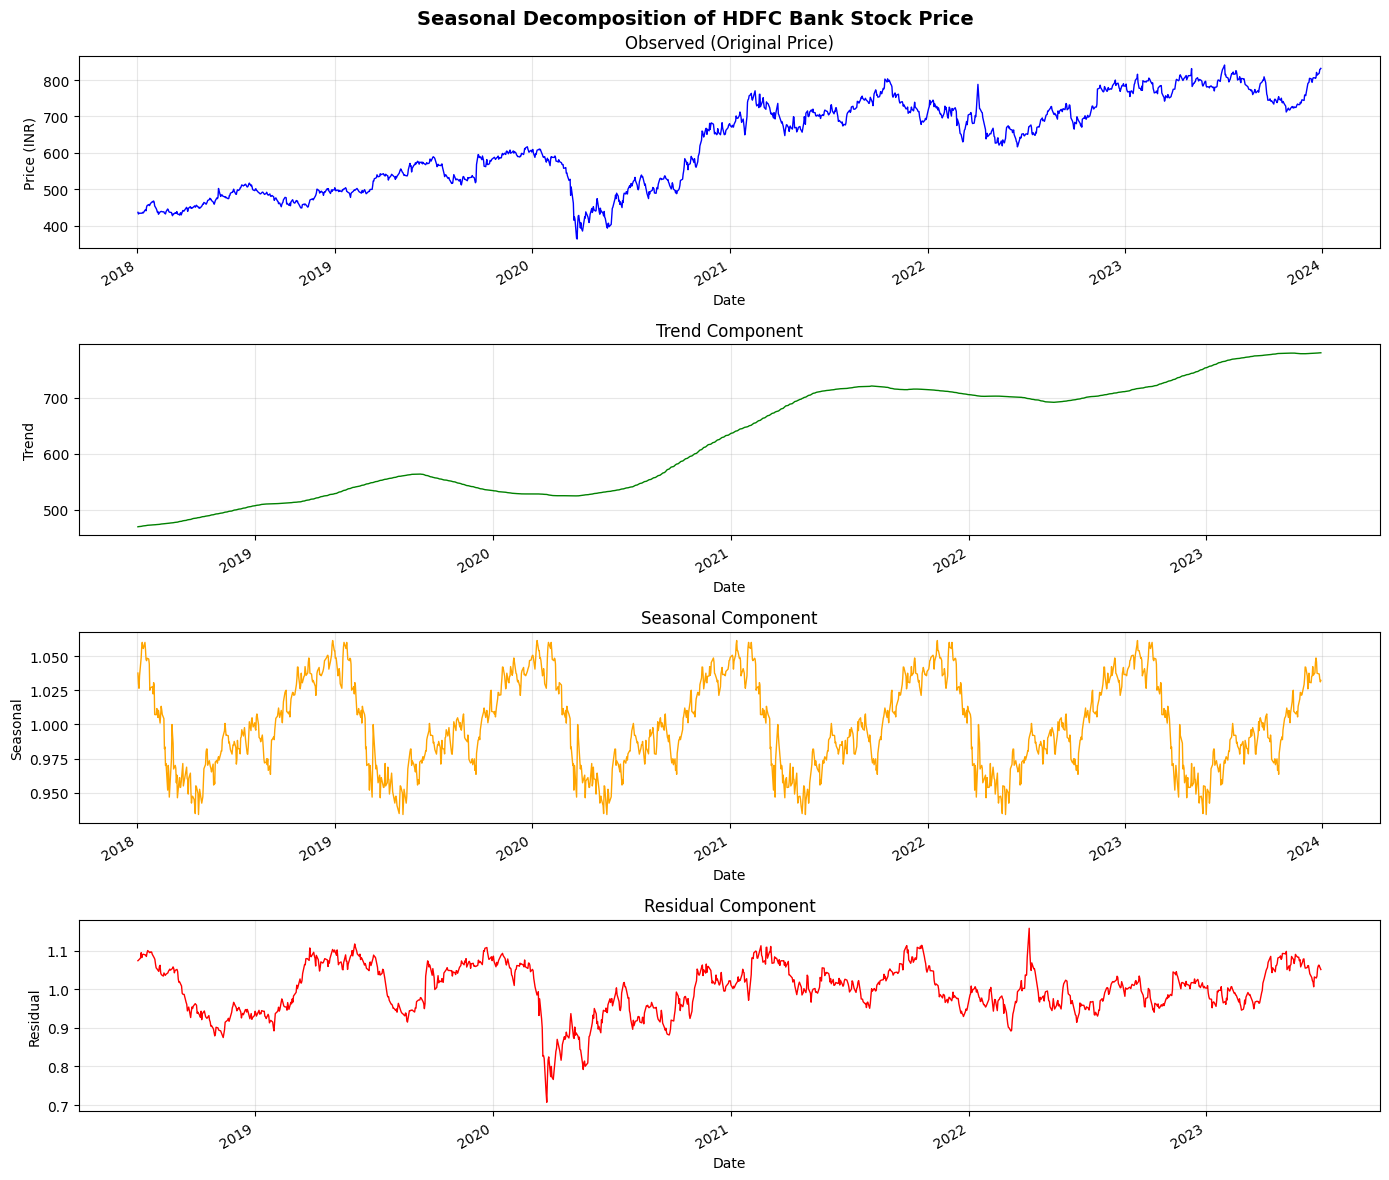


2. CHECKING STATIONARITY FOR SARIMA
--------------------------------------------------
ADF Test on Differenced Price:
ADF Statistic: -14.369854
p-value: 0.000000
✓ Series is stationary after differencing (d=1)

3. ACF/PACF ANALYSIS
--------------------------------------------------


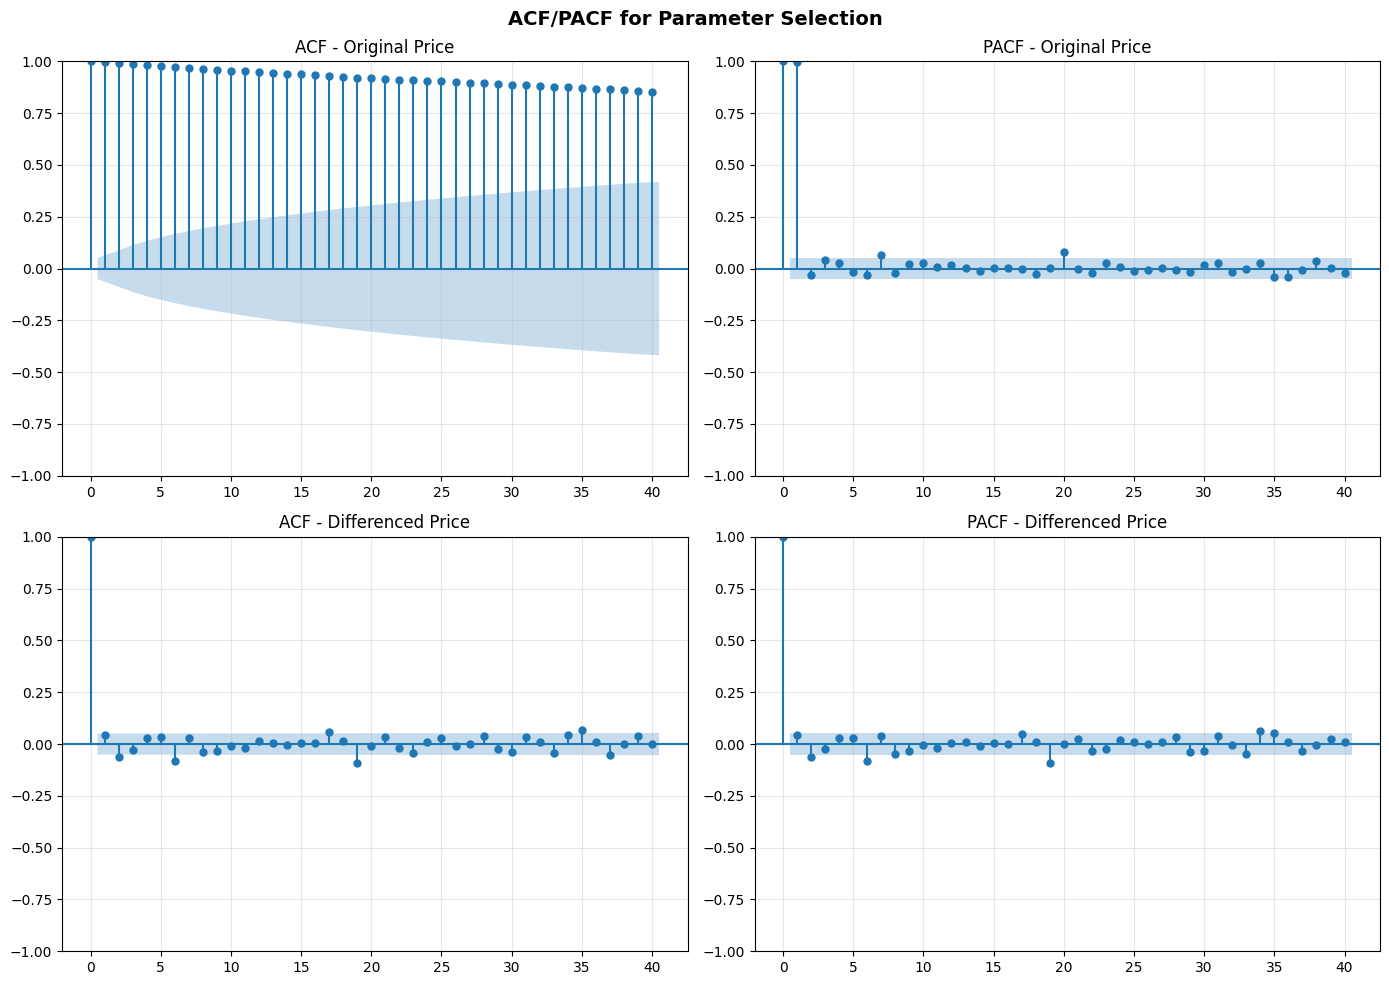


4. SARIMA PARAMETERS
--------------------------------------------------
Non-seasonal order (p,d,q): (1, 1, 1)
Seasonal order (P,D,Q,s): (1, 1, 1, 12)

5. TRAINING SARIMA MODEL
--------------------------------------------------
Training data size: 1184 days
Test data size: 296 days

✓ SARIMA Model Fitted Successfully
Log Likelihood: -4292.00
AIC: 8594.01
BIC: 8619.28

6. MAKING PREDICTIONS
--------------------------------------------------

7. SARIMA PERFORMANCE METRICS
--------------------------------------------------
RMSE: 60.3649
MAE: 53.9791
MAPE: 6.85%
R² Score: -3.1414

8. DIAGNOSTIC CHECKS
--------------------------------------------------

Ljung-Box Test for Residual Autocorrelation:
        lb_stat  lb_pvalue
10  2061.214613        0.0
20  3083.194772        0.0
⚠ Significant autocorrelation detected

Jarque-Bera Test for Normality:
JB Statistic: 34.2529
p-value: 0.0000
⚠ Residuals are not normally distributed

9. GENERATING VISUALIZATIONS
------------------------------------

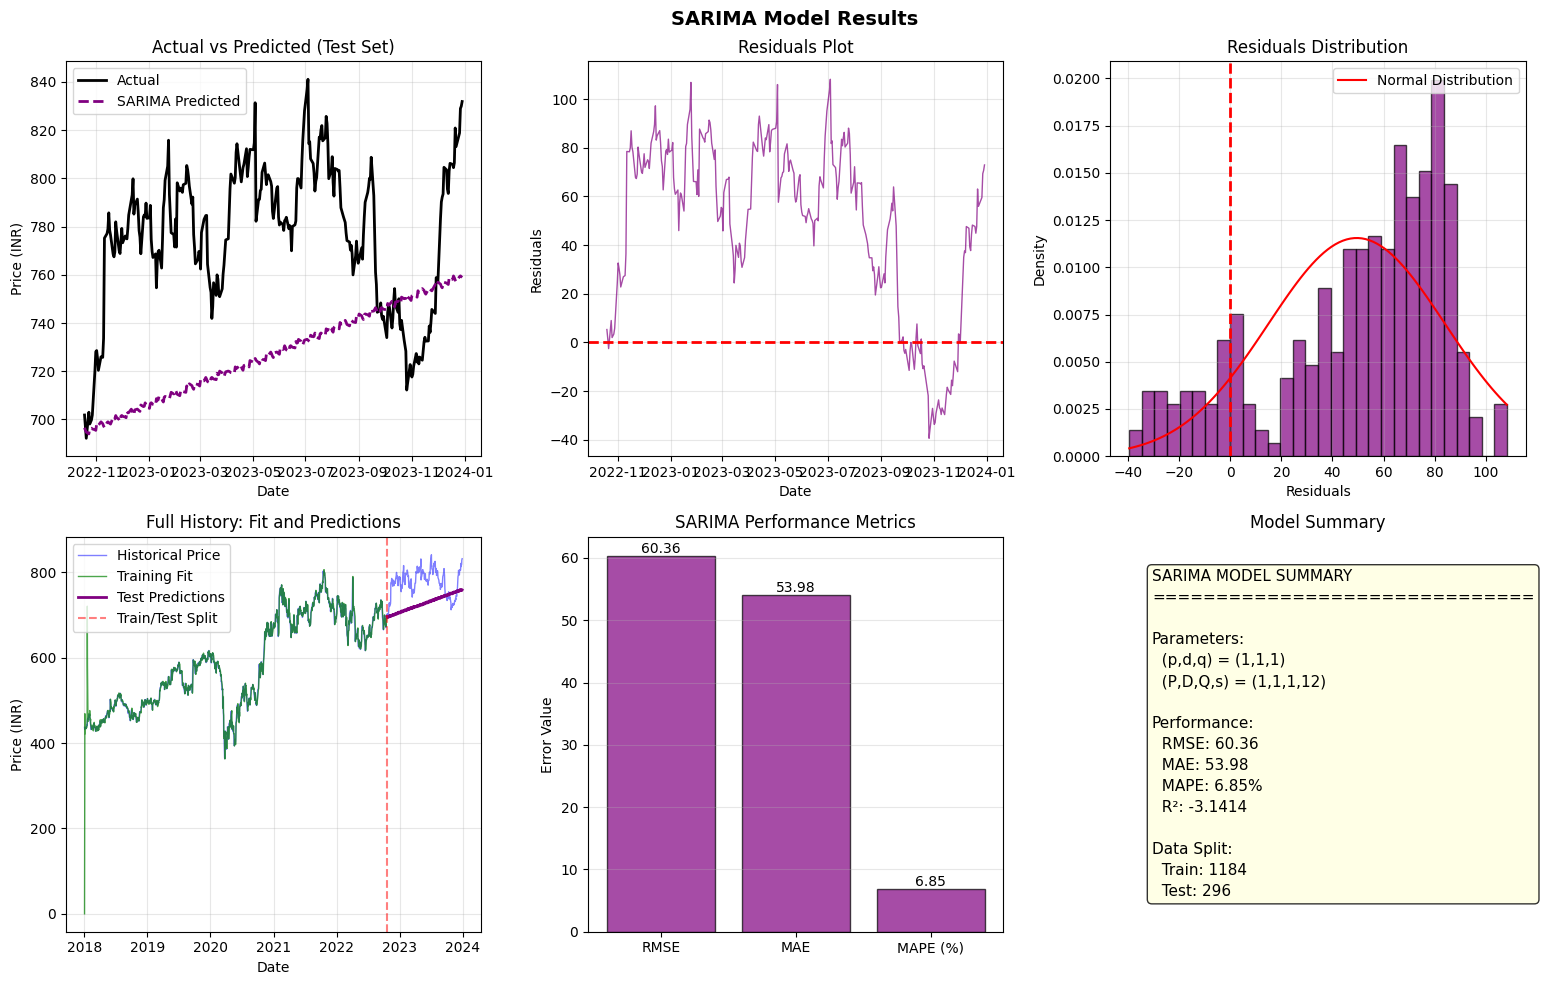


10. FUTURE FORECAST (30 DAYS)
--------------------------------------------------

Next 10 Days Forecast:
      Date  SARIMA_Forecast
2024-01-01       696.562363
2024-01-02       695.496608
2024-01-03       694.752726
2024-01-04       694.009645
2024-01-05       696.138278
2024-01-08       696.371400
2024-01-09       696.081340
2024-01-10       695.718394
2024-01-11       695.476584
2024-01-12       698.111331


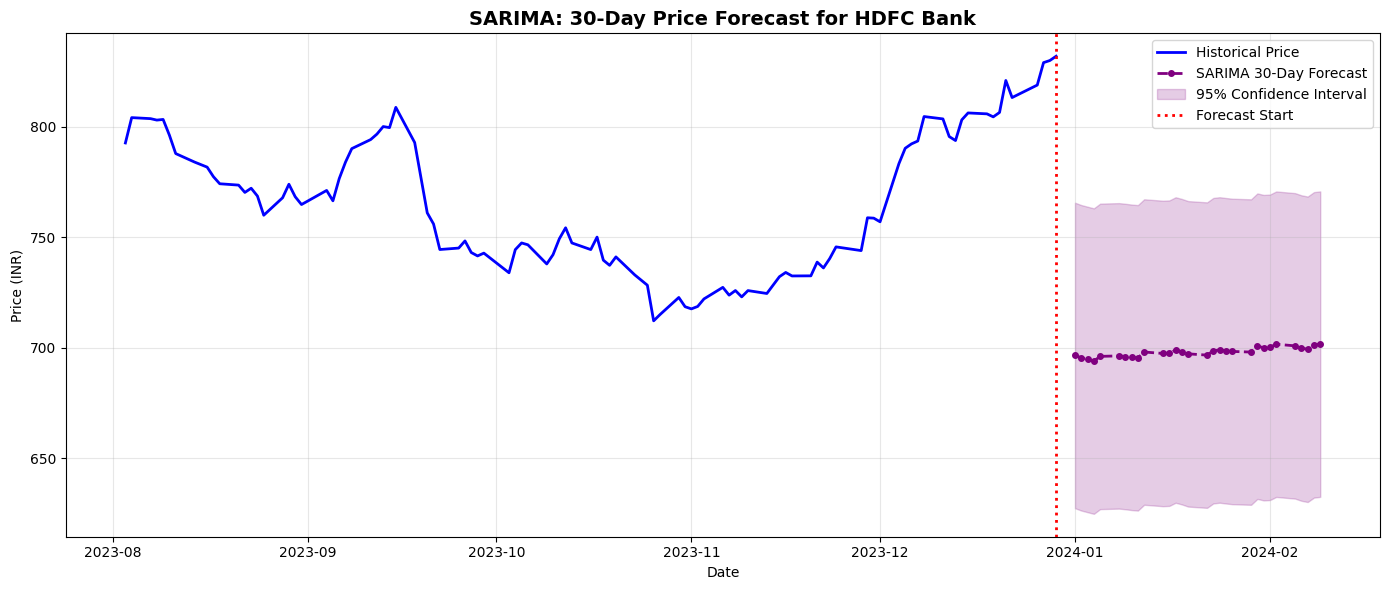


Forecast Statistics:
Initial Forecast Price: 696.56
Final Forecast Price: 701.68
Expected Change: 5.11 INR
Expected Return: 0.73%
Forecast Volatility (Std Dev): 34.53

PART 7 COMPLETED - SARIMA MODEL SUCCESSFULLY IMPLEMENTED


In [ ]:
# ============================================================================
# PART 7: SARIMA MODEL WITH SEASONALITY (Standalone - No Dependencies)
# ============================================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.metrics import r2_score
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("PART 7: SARIMA MODEL WITH SEASONALITY")
print("="*70)

# 1. Seasonal Decomposition
print("\n1. SEASONAL DECOMPOSITION")
print("-"*50)

# Decompose the price series
decomposition = seasonal_decompose(df_clean['Price'], model='multiplicative', period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Seasonal Decomposition of HDFC Bank Stock Price', fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], title='Observed (Original Price)', color='blue', linewidth=1)
axes[0].set_ylabel('Price (INR)')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], title='Trend Component', color='green', linewidth=1)
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component', color='orange', linewidth=1)
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], title='Residual Component', color='red', linewidth=1)
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Check Stationarity
print("\n2. CHECKING STATIONARITY FOR SARIMA")
print("-"*50)

price_diff = df_clean['Price'].diff().dropna()

from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(price_diff)
print(f"ADF Test on Differenced Price:")
print(f"ADF Statistic: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")

if adf_result[1] < 0.05:
    print("✓ Series is stationary after differencing (d=1)")
else:
    print("⚠ Series may need further differencing")

# 3. ACF/PACF Plots
print("\n3. ACF/PACF ANALYSIS")
print("-"*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ACF/PACF for Parameter Selection', fontsize=14, fontweight='bold')

plot_acf(df_clean['Price'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Original Price')
axes[0, 0].grid(True, alpha=0.3)

plot_pacf(df_clean['Price'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title('PACF - Original Price')
axes[0, 1].grid(True, alpha=0.3)

plot_acf(price_diff, lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF - Differenced Price')
axes[1, 0].grid(True, alpha=0.3)

plot_pacf(price_diff, lags=40, ax=axes[1, 1])
axes[1, 1].set_title('PACF - Differenced Price')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. SARIMA Parameters
print("\n4. SARIMA PARAMETERS")
print("-"*50)

# Default parameters for stock data
p_param, d_param, q_param = 1, 1, 1
P_param, D_param, Q_param, s_param = 1, 1, 1, 12

print(f"Non-seasonal order (p,d,q): ({p_param}, {d_param}, {q_param})")
print(f"Seasonal order (P,D,Q,s): ({P_param}, {D_param}, {Q_param}, {s_param})")

# 5. Train SARIMA Model
print("\n5. TRAINING SARIMA MODEL")
print("-"*50)

# Split data
train_size = int(len(df_clean) * 0.8)
train_data = df_clean['Price'][:train_size]
test_data = df_clean['Price'][train_size:]

print(f"Training data size: {len(train_data)} days")
print(f"Test data size: {len(test_data)} days")

# Fit SARIMA model
sarima_model = SARIMAX(
    train_data,
    order=(p_param, d_param, q_param),
    seasonal_order=(P_param, D_param, Q_param, s_param),
    enforce_stationarity=False,
    enforce_invertibility=False,
    disp=False
)

try:
    sarima_fitted = sarima_model.fit(disp=False)
    print("\n✓ SARIMA Model Fitted Successfully")
    print(f"Log Likelihood: {sarima_fitted.llf:.2f}")
    print(f"AIC: {sarima_fitted.aic:.2f}")
    print(f"BIC: {sarima_fitted.bic:.2f}")
except Exception as e:
    print(f"Fitting with fallback parameters...")
    sarima_model = SARIMAX(
        train_data,
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
        disp=False
    )
    sarima_fitted = sarima_model.fit(disp=False)
    print("✓ SARIMA Model Fitted with fallback parameters")

# 6. Make Predictions
print("\n6. MAKING PREDICTIONS")
print("-"*50)

sarima_predictions = sarima_fitted.forecast(steps=len(test_data))
train_predictions = sarima_fitted.predict(start=0, end=len(train_data)-1)

# 7. Calculate Metrics
print("\n7. SARIMA PERFORMANCE METRICS")
print("-"*50)

sarima_rmse = np.sqrt(np.mean((test_data.values - sarima_predictions)**2))
sarima_mae = np.mean(np.abs(test_data.values - sarima_predictions))
sarima_mape = np.mean(np.abs((test_data.values - sarima_predictions) / test_data.values)) * 100
sarima_r2 = r2_score(test_data.values, sarima_predictions)

print(f"RMSE: {sarima_rmse:.4f}")
print(f"MAE: {sarima_mae:.4f}")
print(f"MAPE: {sarima_mape:.2f}%")
print(f"R² Score: {sarima_r2:.4f}")

# 8. Diagnostic Checks
print("\n8. DIAGNOSTIC CHECKS")
print("-"*50)

residuals = test_data.values - sarima_predictions

# Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\nLjung-Box Test for Residual Autocorrelation:")
print(lb_test)

if lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("✓ No significant autocorrelation in residuals")
else:
    print("⚠ Significant autocorrelation detected")

# Jarque-Bera test
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"\nJarque-Bera Test for Normality:")
print(f"JB Statistic: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")

if jb_pvalue > 0.05:
    print("✓ Residuals appear normally distributed")
else:
    print("⚠ Residuals are not normally distributed")

# 9. Visualizations
print("\n9. GENERATING VISUALIZATIONS")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SARIMA Model Results', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0, 0].plot(test_data.index, test_data.values, label='Actual', color='black', linewidth=2)
axes[0, 0].plot(test_data.index, sarima_predictions, label='SARIMA Predicted', color='purple', linestyle='--', linewidth=2)
axes[0, 0].set_title('Actual vs Predicted (Test Set)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (INR)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals Plot
axes[0, 1].plot(test_data.index, residuals, color='purple', alpha=0.7, linewidth=1)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals Plot')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Residuals Distribution
axes[0, 2].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='purple', density=True)
axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('Residuals Distribution')
axes[0, 2].set_xlabel('Residuals')
axes[0, 2].set_ylabel('Density')
axes[0, 2].grid(True, alpha=0.3)

# Add normal curve
mu, std = np.mean(residuals), np.std(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 2].plot(x, stats.norm.pdf(x, mu, std), 'r-', label='Normal Distribution')
axes[0, 2].legend()

# Full History
axes[1, 0].plot(df_clean.index, df_clean['Price'], label='Historical Price', color='blue', alpha=0.5, linewidth=1)
axes[1, 0].plot(train_data.index, train_predictions, label='Training Fit', color='green', alpha=0.7, linewidth=1)
axes[1, 0].plot(test_data.index, sarima_predictions, label='Test Predictions', color='purple', linewidth=2)
axes[1, 0].axvline(x=train_data.index[-1], color='red', linestyle='--', alpha=0.5, label='Train/Test Split')
axes[1, 0].set_title('Full History: Fit and Predictions')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price (INR)')
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# Metrics Bar Chart
metrics_to_plot = ['RMSE', 'MAE', 'MAPE (%)']
metric_values = [sarima_rmse, sarima_mae, sarima_mape]

bars = axes[1, 1].bar(metrics_to_plot, metric_values, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title('SARIMA Performance Metrics')
axes[1, 1].set_ylabel('Error Value')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, metric_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{value:.2f}', ha='center', va='bottom', fontsize=10)

# Summary Text
summary_text = f"SARIMA MODEL SUMMARY\n"
summary_text += "="*30 + "\n\n"
summary_text += f"Parameters:\n"
summary_text += f"  (p,d,q) = ({p_param},{d_param},{q_param})\n"
summary_text += f"  (P,D,Q,s) = ({P_param},{D_param},{Q_param},{s_param})\n\n"
summary_text += f"Performance:\n"
summary_text += f"  RMSE: {sarima_rmse:.2f}\n"
summary_text += f"  MAE: {sarima_mae:.2f}\n"
summary_text += f"  MAPE: {sarima_mape:.2f}%\n"
summary_text += f"  R²: {sarima_r2:.4f}\n\n"
summary_text += f"Data Split:\n"
summary_text += f"  Train: {len(train_data)}\n"
summary_text += f"  Test: {len(test_data)}"

axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11,
                verticalalignment='center', linespacing=1.5,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('Model Summary')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 10. Future Forecast (30 Days)
print("\n10. FUTURE FORECAST (30 DAYS)")
print("-"*50)

future_forecast = sarima_fitted.forecast(steps=30)
future_dates = pd.date_range(start=df_clean.index[-1] + timedelta(days=1), periods=30, freq='B')

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'SARIMA_Forecast': future_forecast.values
})

print("\nNext 10 Days Forecast:")
print(forecast_df.head(10).to_string(index=False))

# Plot future forecast
plt.figure(figsize=(14, 6))

plt.plot(df_clean.index[-100:], df_clean['Price'].values[-100:],
         label='Historical Price', color='blue', linewidth=2)

plt.plot(future_dates, future_forecast, label='SARIMA 30-Day Forecast',
         color='purple', linestyle='--', linewidth=2, marker='o', markersize=4)

# Confidence intervals
forecast_std = np.std(residuals)
plt.fill_between(future_dates,
                 future_forecast - 2*forecast_std,
                 future_forecast + 2*forecast_std,
                 color='purple', alpha=0.2, label='95% Confidence Interval')

plt.axvline(x=df_clean.index[-1], color='red', linestyle=':',
            linewidth=2, label='Forecast Start')

plt.title('SARIMA: 30-Day Price Forecast for HDFC Bank', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Forecast Statistics (Fixed - No KeyError)
print("\nForecast Statistics:")
print(f"Initial Forecast Price: {future_forecast.iloc[0]:.2f}")
print(f"Final Forecast Price: {future_forecast.iloc[-1]:.2f}")
print(f"Expected Change: {future_forecast.iloc[-1] - future_forecast.iloc[0]:.2f} INR")
print(f"Expected Return: {((future_forecast.iloc[-1] / future_forecast.iloc[0]) - 1) * 100:.2f}%")
print(f"Forecast Volatility (Std Dev): {forecast_std:.2f}")

print("\n" + "="*70)
print("PART 7 SARIMA MODEL SUCCESSFULLY IMPLEMENTED")
print("="*70)

# COMPREHENSIVE MODEL COMPARISON (LSTM vs N-BEATS vs SARIMA)


PART 8: COMPREHENSIVE MODEL COMPARISON
LSTM vs N-BEATS vs SARIMA

SECTION 1: COLLECTING AND ALIGNING RESULTS FROM ALL MODELS

1.1 LSTM MODEL RESULTS
--------------------------------------------------
✓ LSTM predictions found
  Aligned length: 284
  RMSE: 13.5315
  MAE: 10.4777
  MAPE: 1.35%
  R²: 0.7428
  Directional Accuracy: 50.53%

1.2 N-BEATS MODEL RESULTS
--------------------------------------------------
✗ N-BEATS results not found. Please run Part 6 first.

1.3 SARIMA MODEL RESULTS
--------------------------------------------------
✓ SARIMA predictions found
  Aligned length: 296
  RMSE: 60.3649
  MAE: 53.9791
  MAPE: 6.85%
  R²: -3.1414
  Directional Accuracy: 49.49%

SECTION 2: ALIGNING ALL MODELS FOR FAIR COMPARISON
Common length for comparison: 284
  LSTM: trimmed to 284 observations
  SARIMA: trimmed to 284 observations

SECTION 3: COMPREHENSIVE METRICS COMPARISON

--------------------------------------------------------------------------------
MODEL PERFORMANCE METRICS CO

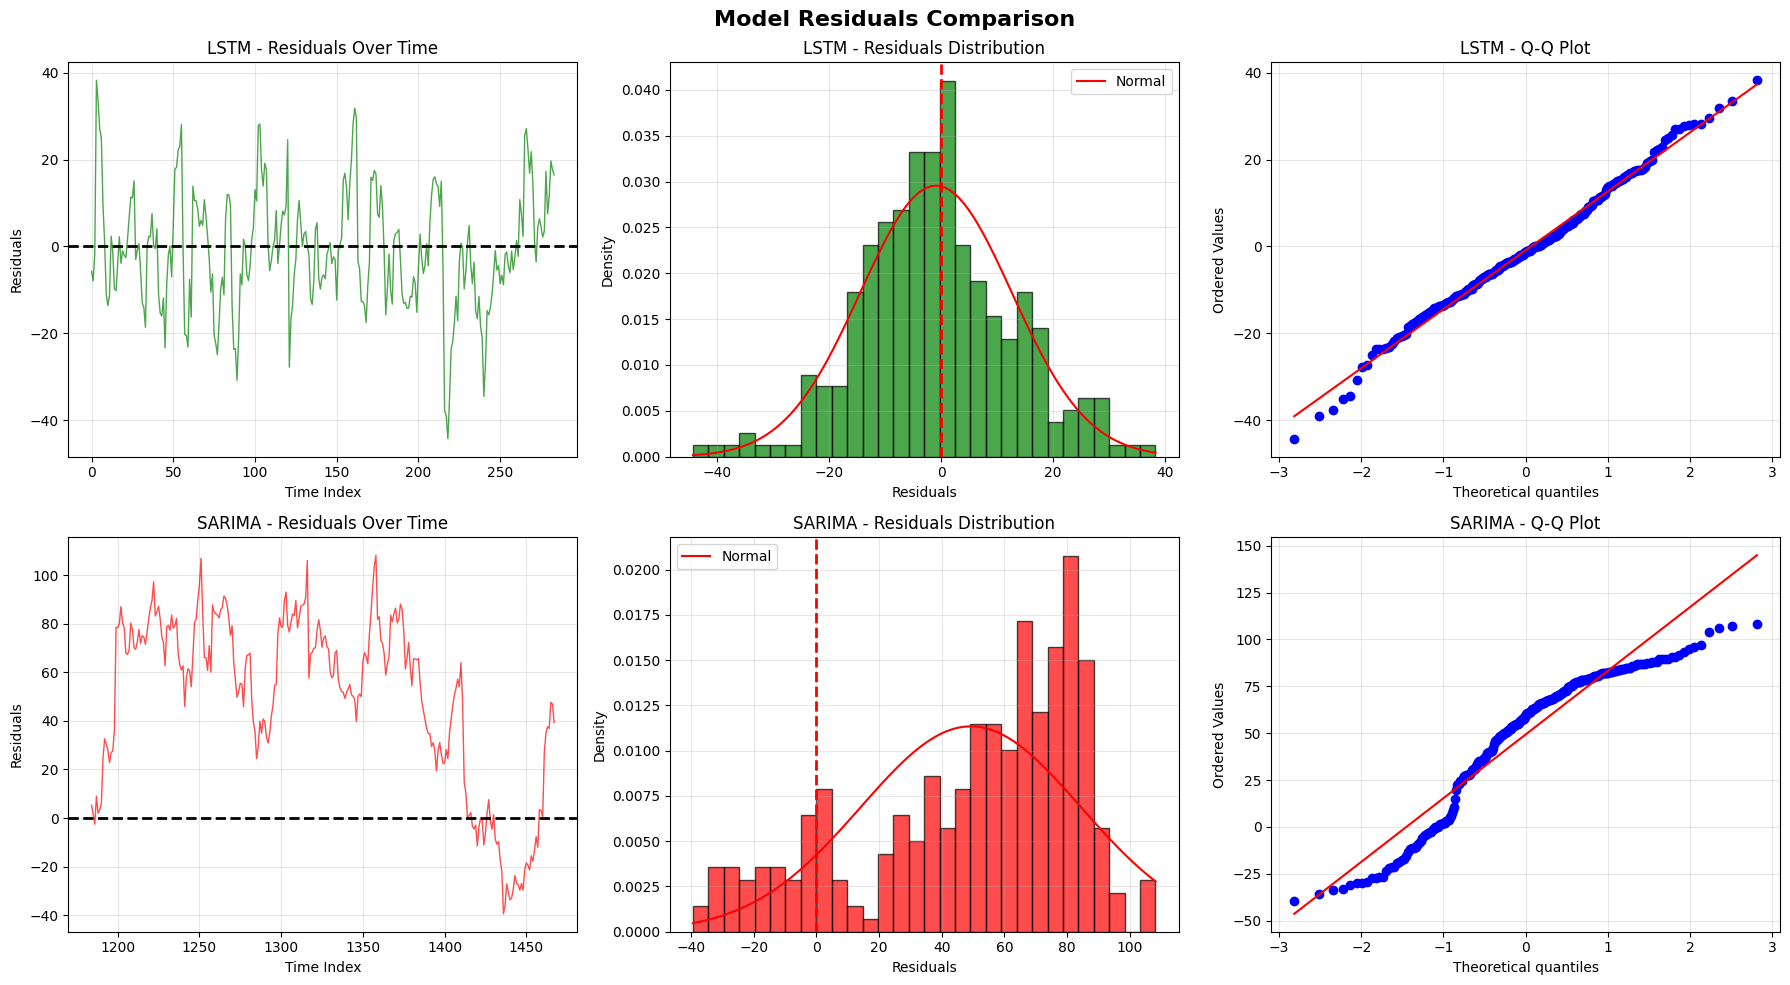


SECTION 6: PREDICTION VISUALIZATION COMPARISON


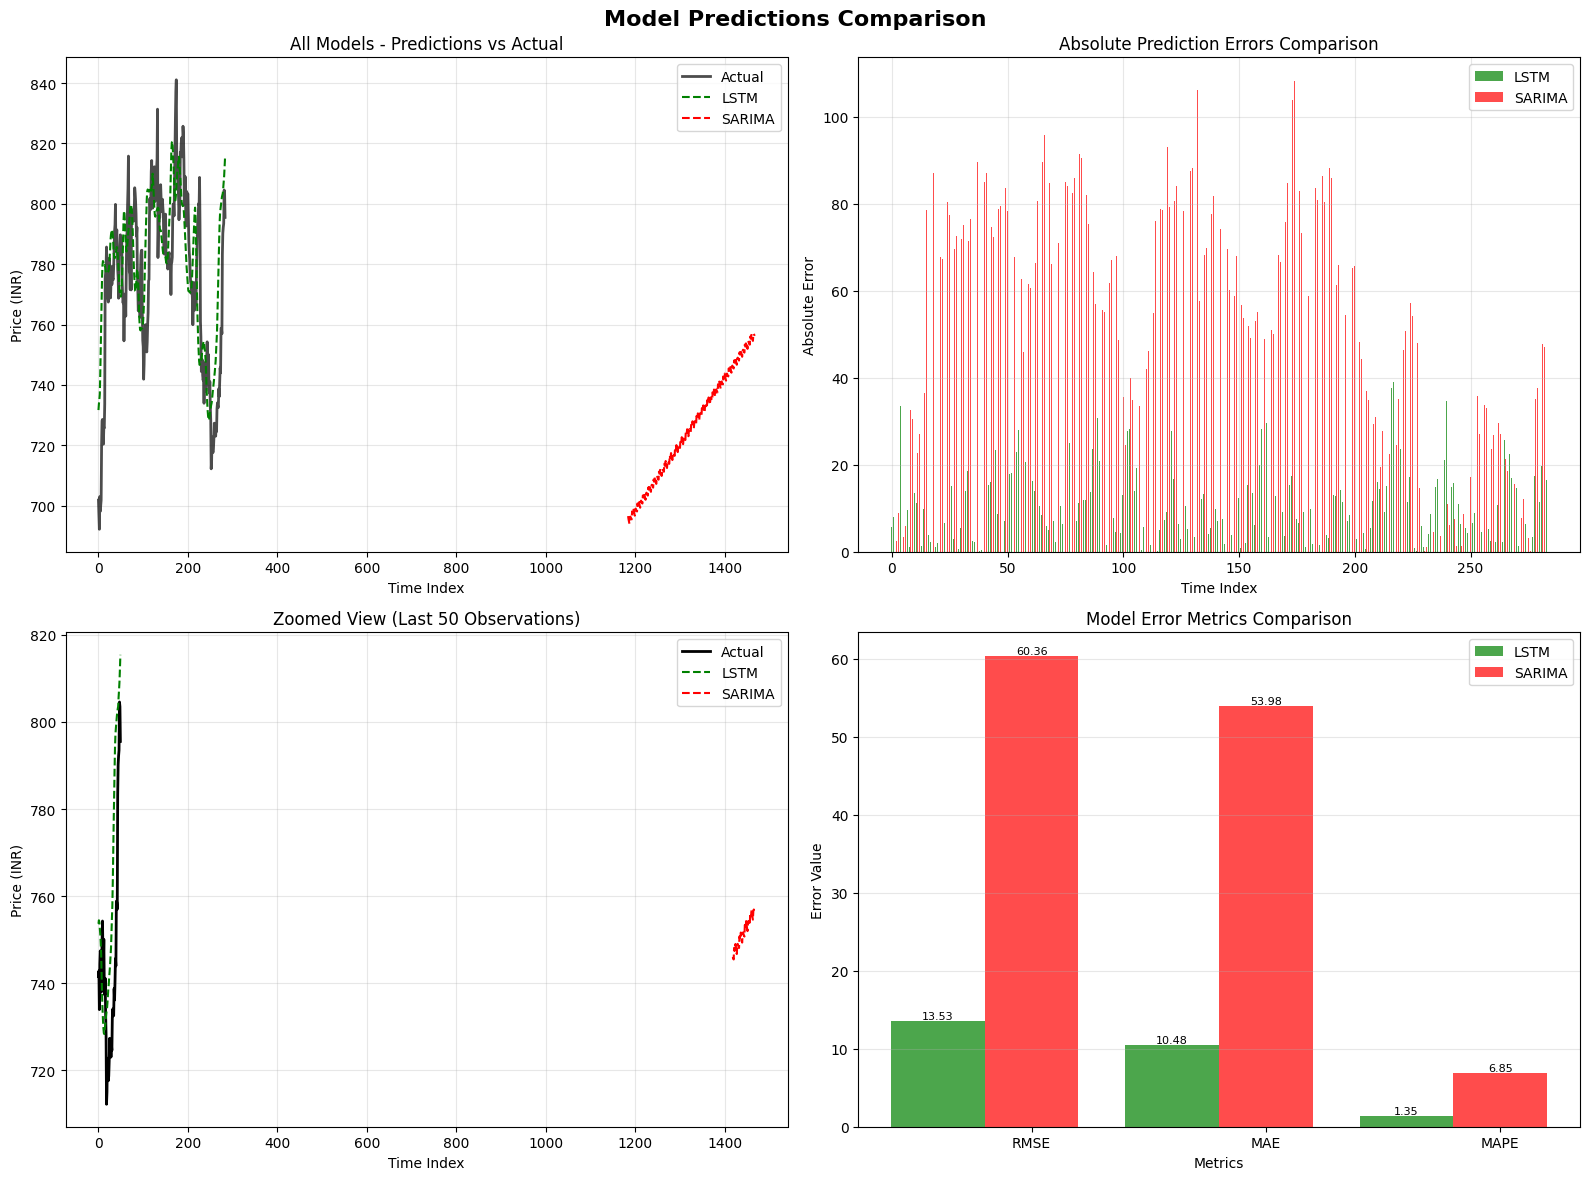


SECTION 7: FINAL RECOMMENDATION

📊 Based on comprehensive analysis of 2 models:

🏆 RECOMMENDED MODEL: LSTM
   → RMSE: 13.5315

SUMMARY TABLE

LSTM:
  RMSE: 13.5315
  MAE: 10.4777
  MAPE: 1.35%
  R²: 0.7428
  Directional Accuracy: 50.53%

SARIMA:
  RMSE: 60.3649
  MAE: 53.9791
  MAPE: 6.85%
  R²: -3.1414
  Directional Accuracy: 49.49%



In [ ]:
# ============================================================================
# PART 8: COMPREHENSIVE MODEL COMPARISON (LSTM vs N-BEATS vs SARIMA)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("PART 8: COMPREHENSIVE MODEL COMPARISON")
print("LSTM vs N-BEATS vs SARIMA")
print("="*80)

# ============================================================================
# SECTION 1: COLLECT AND ALIGN RESULTS FROM ALL THREE MODELS
# ============================================================================

print("\n" + "="*80)
print("SECTION 1: COLLECTING AND ALIGNING RESULTS FROM ALL MODELS")
print("="*80)

# 1.1 LSTM Results (from Part 5)
print("\n1.1 LSTM MODEL RESULTS")
print("-"*50)

lstm_metrics = None
try:
    if 'lstm_predictions' in dir() and 'lstm_actual' in dir():
        print("✓ LSTM predictions found")

        # Align LSTM lengths
        min_len_lstm = min(len(lstm_actual), len(lstm_predictions))
        lstm_actual_aligned = lstm_actual[:min_len_lstm]
        lstm_predictions_aligned = lstm_predictions[:min_len_lstm]

        print(f"  Aligned length: {min_len_lstm}")

        # Calculate LSTM metrics
        lstm_rmse = np.sqrt(mean_squared_error(lstm_actual_aligned, lstm_predictions_aligned))
        lstm_mae = mean_absolute_error(lstm_actual_aligned, lstm_predictions_aligned)
        lstm_mape = np.mean(np.abs((lstm_actual_aligned - lstm_predictions_aligned) / lstm_actual_aligned)) * 100
        lstm_r2 = r2_score(lstm_actual_aligned, lstm_predictions_aligned)

        # Directional Accuracy
        if len(lstm_actual_aligned) > 1:
            lstm_actual_direction = np.diff(lstm_actual_aligned) > 0
            lstm_pred_direction = np.diff(lstm_predictions_aligned) > 0
            lstm_directional_acc = np.mean(lstm_actual_direction == lstm_pred_direction) * 100
        else:
            lstm_directional_acc = np.nan

        # Residuals
        lstm_residuals = lstm_actual_aligned - lstm_predictions_aligned

        lstm_metrics = {
            'RMSE': lstm_rmse,
            'MAE': lstm_mae,
            'MAPE': lstm_mape,
            'R2': lstm_r2,
            'Directional Accuracy': lstm_directional_acc,
            'Residuals': lstm_residuals,
            'Actual': lstm_actual_aligned,
            'Predictions': lstm_predictions_aligned
        }

        print(f"  RMSE: {lstm_rmse:.4f}")
        print(f"  MAE: {lstm_mae:.4f}")
        print(f"  MAPE: {lstm_mape:.2f}%")
        print(f"  R²: {lstm_r2:.4f}")
        print(f"  Directional Accuracy: {lstm_directional_acc:.2f}%")

    else:
        print("✗ LSTM results not found. Please run Part 5 first.")

except Exception as e:
    print(f"✗ Error loading LSTM results: {e}")

# 1.2 N-BEATS Results (from Part 6)
print("\n1.2 N-BEATS MODEL RESULTS")
print("-"*50)

nbeats_metrics = None
try:
    if 'nbeats_predictions' in dir() and 'nbeats_actual' in dir():
        print("✓ N-BEATS predictions found")

        # Align N-BEATS lengths
        min_len_nbeats = min(len(nbeats_actual), len(nbeats_predictions))
        nbeats_actual_aligned = nbeats_actual[:min_len_nbeats]
        nbeats_predictions_aligned = nbeats_predictions[:min_len_nbeats]

        print(f"  Aligned length: {min_len_nbeats}")

        # Calculate N-BEATS metrics
        nbeats_rmse = np.sqrt(mean_squared_error(nbeats_actual_aligned, nbeats_predictions_aligned))
        nbeats_mae = mean_absolute_error(nbeats_actual_aligned, nbeats_predictions_aligned)
        nbeats_mape = np.mean(np.abs((nbeats_actual_aligned - nbeats_predictions_aligned) / nbeats_actual_aligned)) * 100
        nbeats_r2 = r2_score(nbeats_actual_aligned, nbeats_predictions_aligned)

        # Directional Accuracy
        if len(nbeats_actual_aligned) > 1:
            nbeats_actual_direction = np.diff(nbeats_actual_aligned) > 0
            nbeats_pred_direction = np.diff(nbeats_predictions_aligned) > 0
            nbeats_directional_acc = np.mean(nbeats_actual_direction == nbeats_pred_direction) * 100
        else:
            nbeats_directional_acc = np.nan

        # Residuals
        nbeats_residuals = nbeats_actual_aligned - nbeats_predictions_aligned

        nbeats_metrics = {
            'RMSE': nbeats_rmse,
            'MAE': nbeats_mae,
            'MAPE': nbeats_mape,
            'R2': nbeats_r2,
            'Directional Accuracy': nbeats_directional_acc,
            'Residuals': nbeats_residuals,
            'Actual': nbeats_actual_aligned,
            'Predictions': nbeats_predictions_aligned
        }

        print(f"  RMSE: {nbeats_rmse:.4f}")
        print(f"  MAE: {nbeats_mae:.4f}")
        print(f"  MAPE: {nbeats_mape:.2f}%")
        print(f"  R²: {nbeats_r2:.4f}")
        print(f"  Directional Accuracy: {nbeats_directional_acc:.2f}%")

    else:
        print("✗ N-BEATS results not found. Please run Part 6 first.")

except Exception as e:
    print(f"✗ Error loading N-BEATS results: {e}")

# 1.3 SARIMA Results (from Part 7)
print("\n1.3 SARIMA MODEL RESULTS")
print("-"*50)

sarima_metrics = None
try:
    if 'sarima_predictions' in dir() and 'test_data' in dir():
        print("✓ SARIMA predictions found")

        # Get test data
        sarima_actual = test_data.values
        sarima_predictions_aligned = sarima_predictions

        # Align lengths
        min_len_sarima = min(len(sarima_actual), len(sarima_predictions_aligned))
        sarima_actual_aligned = sarima_actual[:min_len_sarima]
        sarima_predictions_aligned = sarima_predictions_aligned[:min_len_sarima]

        print(f"  Aligned length: {min_len_sarima}")

        # Calculate SARIMA metrics
        sarima_rmse = np.sqrt(mean_squared_error(sarima_actual_aligned, sarima_predictions_aligned))
        sarima_mae = mean_absolute_error(sarima_actual_aligned, sarima_predictions_aligned)
        sarima_mape = np.mean(np.abs((sarima_actual_aligned - sarima_predictions_aligned) / sarima_actual_aligned)) * 100
        sarima_r2 = r2_score(sarima_actual_aligned, sarima_predictions_aligned)

        # Directional Accuracy
        if len(sarima_actual_aligned) > 1:
            sarima_actual_direction = np.diff(sarima_actual_aligned) > 0
            sarima_pred_direction = np.diff(sarima_predictions_aligned) > 0
            sarima_directional_acc = np.mean(sarima_actual_direction == sarima_pred_direction) * 100
        else:
            sarima_directional_acc = np.nan

        # Residuals
        sarima_residuals = sarima_actual_aligned - sarima_predictions_aligned

        sarima_metrics = {
            'RMSE': sarima_rmse,
            'MAE': sarima_mae,
            'MAPE': sarima_mape,
            'R2': sarima_r2,
            'Directional Accuracy': sarima_directional_acc,
            'Residuals': sarima_residuals,
            'Actual': sarima_actual_aligned,
            'Predictions': sarima_predictions_aligned
        }

        print(f"  RMSE: {sarima_rmse:.4f}")
        print(f"  MAE: {sarima_mae:.4f}")
        print(f"  MAPE: {sarima_mape:.2f}%")
        print(f"  R²: {sarima_r2:.4f}")
        print(f"  Directional Accuracy: {sarima_directional_acc:.2f}%")

    else:
        print("✗ SARIMA results not found. Please run Part 7 first.")

except Exception as e:
    print(f"✗ Error loading SARIMA results: {e}")

# ============================================================================
# SECTION 2: ALIGN ALL MODELS TO SAME LENGTH FOR COMPARISON
# ============================================================================

print("\n" + "="*80)
print("SECTION 2: ALIGNING ALL MODELS FOR FAIR COMPARISON")
print("="*80)

# Find the minimum length across all available models
available_models = []
all_lengths = []

if lstm_metrics:
    available_models.append(('LSTM', lstm_metrics))
    all_lengths.append(len(lstm_metrics['Residuals']))

if nbeats_metrics:
    available_models.append(('N-BEATS', nbeats_metrics))
    all_lengths.append(len(nbeats_metrics['Residuals']))

if sarima_metrics:
    available_models.append(('SARIMA', sarima_metrics))
    all_lengths.append(len(sarima_metrics['Residuals']))

if all_lengths:
    common_length = min(all_lengths)
    print(f"Common length for comparison: {common_length}")

    # Trim all models to common length
    for name, metrics in available_models:
        metrics['Residuals'] = metrics['Residuals'][:common_length]
        metrics['Actual'] = metrics['Actual'][:common_length]
        metrics['Predictions'] = metrics['Predictions'][:common_length]
        print(f"  {name}: trimmed to {len(metrics['Residuals'])} observations")

# ============================================================================
# SECTION 3: COMPREHENSIVE METRICS COMPARISON
# ============================================================================

print("\n" + "="*80)
print("SECTION 3: COMPREHENSIVE METRICS COMPARISON")
print("="*80)

if available_models:
    # Create comparison dataframe
    comparison_data = []
    model_names = []

    for name, metrics in available_models:
        comparison_data.append({
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE': metrics['MAPE'],
            'R2': metrics['R2'],
            'Directional Accuracy': metrics['Directional Accuracy']
        })
        model_names.append(name)

    comparison_df = pd.DataFrame(comparison_data, index=model_names)

    # Display metrics table
    print("\n" + "-"*80)
    print("MODEL PERFORMANCE METRICS COMPARISON")
    print("-"*80)

    display_df = comparison_df.copy()
    display_df['RMSE'] = display_df['RMSE'].map('{:.4f}'.format)
    display_df['MAE'] = display_df['MAE'].map('{:.4f}'.format)
    display_df['MAPE'] = display_df['MAPE'].map('{:.2f}%'.format)
    display_df['R2'] = display_df['R2'].map('{:.4f}'.format)
    display_df['Directional Accuracy'] = display_df['Directional Accuracy'].map('{:.2f}%'.format)

    print(display_df.to_string())

    # Determine best model for each metric
    print("\n" + "-"*80)
    print("BEST MODEL FOR EACH METRIC")
    print("-"*80)

    # For error metrics (lower is better)
    error_metrics = ['RMSE', 'MAE', 'MAPE']
    for metric in error_metrics:
        if metric in comparison_df.columns:
            best_idx = comparison_df[metric].idxmin()
            best_value = comparison_df.loc[best_idx, metric]
            print(f"✓ {metric:20s}: {best_idx:10s} ({best_value:.4f})")

    # For R2 and Directional Accuracy (higher is better)
    higher_better = ['R2', 'Directional Accuracy']
    for metric in higher_better:
        if metric in comparison_df.columns:
            best_idx = comparison_df[metric].idxmax()
            best_value = comparison_df.loc[best_idx, metric]
            print(f"✓ {metric:20s}: {best_idx:10s} ({best_value:.4f})")

    # Overall ranking by RMSE
    print("\n" + "-"*80)
    print("OVERALL MODEL RANKING (by RMSE)")
    print("-"*80)

    ranked_models = comparison_df.sort_values('RMSE')
    for rank, (model, row) in enumerate(ranked_models.iterrows(), 1):
        print(f"{rank}. {model:10s} - RMSE: {row['RMSE']:.4f}, MAPE: {row['MAPE']:.2f}%")

# ============================================================================
# SECTION 4: STATISTICAL SIGNIFICANCE TESTS (FIXED)
# ============================================================================

print("\n" + "="*80)
print("SECTION 4: STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

def compare_models_statistically(metrics1, metrics2, name1, name2):
    """
    Perform statistical tests to compare model performance
    """
    residuals1 = metrics1['Residuals']
    residuals2 = metrics2['Residuals']

    # Ensure same length
    min_len = min(len(residuals1), len(residuals2))
    residuals1 = residuals1[:min_len]
    residuals2 = residuals2[:min_len]

    print(f"\nComparing {name1} vs {name2} (based on {min_len} observations):")
    print("-"*50)

    # Calculate squared errors
    mse1 = residuals1 ** 2
    mse2 = residuals2 ** 2

    # Paired t-test
    try:
        t_stat, p_value = stats.ttest_rel(mse1, mse2)

        print(f"Paired t-test on squared errors:")
        print(f"  t-statistic: {t_stat:.4f}")
        print(f"  p-value: {p_value:.6f}")

        if p_value < 0.05:
            if np.mean(mse1) < np.mean(mse2):
                print(f"  → {name1} has significantly lower error (better)")
            else:
                print(f"  → {name2} has significantly lower error (better)")
        else:
            print(f"  → No significant difference between models")
    except Exception as e:
        print(f"  Could not perform t-test: {e}")

    # Wilcoxon signed-rank test (non-parametric)
    try:
        w_stat, w_pvalue = stats.wilcoxon(np.abs(residuals1), np.abs(residuals2))
        print(f"\nWilcoxon signed-rank test:")
        print(f"  W-statistic: {w_stat:.4f}")
        print(f"  p-value: {w_pvalue:.6f}")

        if w_pvalue < 0.05:
            if np.mean(np.abs(residuals1)) < np.mean(np.abs(residuals2)):
                print(f"  → {name1} has significantly lower absolute error (better)")
            else:
                print(f"  → {name2} has significantly lower absolute error (better)")
        else:
            print(f"  → No significant difference in absolute errors")
    except Exception as e:
        print(f"  Could not perform Wilcoxon test: {e}")

# Compare models pairwise
if len(available_models) >= 2:
    for i in range(len(available_models)):
        for j in range(i+1, len(available_models)):
            name1, metrics1 = available_models[i]
            name2, metrics2 = available_models[j]
            compare_models_statistically(metrics1, metrics2, name1, name2)

# ============================================================================
# SECTION 5: RESIDUAL ANALYSIS COMPARISON
# ============================================================================

print("\n" + "="*80)
print("SECTION 5: RESIDUAL ANALYSIS COMPARISON")
print("="*80)

if len(available_models) > 0:
    fig, axes = plt.subplots(len(available_models), 3, figsize=(18, 5*len(available_models)))
    fig.suptitle('Model Residuals Comparison', fontsize=16, fontweight='bold')

    colors = ['green', 'red', 'purple']

    for idx, (model_name, metrics) in enumerate(available_models):
        residuals = metrics['Residuals']

        # Residuals over time
        axes[idx, 0].plot(residuals, color=colors[idx % len(colors)], alpha=0.7, linewidth=1)
        axes[idx, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
        axes[idx, 0].set_title(f'{model_name} - Residuals Over Time')
        axes[idx, 0].set_xlabel('Time Index')
        axes[idx, 0].set_ylabel('Residuals')
        axes[idx, 0].grid(True, alpha=0.3)

        # Residuals distribution
        axes[idx, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7,
                          color=colors[idx % len(colors)], density=True)
        axes[idx, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[idx, 1].set_title(f'{model_name} - Residuals Distribution')
        axes[idx, 1].set_xlabel('Residuals')
        axes[idx, 1].set_ylabel('Density')
        axes[idx, 1].grid(True, alpha=0.3)

        # Add normal curve
        mu, std = np.mean(residuals), np.std(residuals)
        x = np.linspace(residuals.min(), residuals.max(), 100)
        axes[idx, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', label='Normal')
        axes[idx, 1].legend()

        # Q-Q plot
        stats.probplot(residuals, dist="norm", plot=axes[idx, 2])
        axes[idx, 2].set_title(f'{model_name} - Q-Q Plot')
        axes[idx, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================================
# SECTION 6: PREDICTION VISUALIZATION COMPARISON
# ============================================================================

print("\n" + "="*80)
print("SECTION 6: PREDICTION VISUALIZATION COMPARISON")
print("="*80)

if len(available_models) >= 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Predictions Comparison', fontsize=16, fontweight='bold')

    # Use SARIMA actual as reference if available, otherwise use first model
    reference_actual = None
    for name, metrics in available_models:
        if name == 'SARIMA' or reference_actual is None:
            reference_actual = metrics['Actual']

    if reference_actual is not None:
        # Plot 1: All predictions together
        axes[0, 0].plot(reference_actual, label='Actual', color='black', linewidth=2, alpha=0.7)

        colors = ['green', 'red', 'purple']
        for idx, (name, metrics) in enumerate(available_models):
            axes[0, 0].plot(metrics['Predictions'], label=name,
                           color=colors[idx % len(colors)], linestyle='--', linewidth=1.5)

        axes[0, 0].set_title('All Models - Predictions vs Actual')
        axes[0, 0].set_xlabel('Time Index')
        axes[0, 0].set_ylabel('Price (INR)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Plot 2: Error comparison
        x = np.arange(len(reference_actual))
        width = 0.25

        for idx, (name, metrics) in enumerate(available_models):
            errors = np.abs(metrics['Residuals'])
            axes[0, 1].bar(x + (idx - len(available_models)/2) * width, errors,
                          width, label=name, alpha=0.7,
                          color=colors[idx % len(colors)])

        axes[0, 1].set_title('Absolute Prediction Errors Comparison')
        axes[0, 1].set_xlabel('Time Index')
        axes[0, 1].set_ylabel('Absolute Error')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Plot 3: Zoomed view (last 50 observations)
        zoom_start = max(0, len(reference_actual) - 50)
        axes[1, 0].plot(reference_actual[zoom_start:], label='Actual', color='black', linewidth=2)

        for idx, (name, metrics) in enumerate(available_models):
            axes[1, 0].plot(metrics['Predictions'][zoom_start:], label=name,
                           color=colors[idx % len(colors)], linestyle='--', linewidth=1.5)

        axes[1, 0].set_title('Zoomed View (Last 50 Observations)')
        axes[1, 0].set_xlabel('Time Index')
        axes[1, 0].set_ylabel('Price (INR)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Plot 4: Metrics bar chart
        metrics_to_plot = ['RMSE', 'MAE', 'MAPE']
        x_pos = np.arange(len(metrics_to_plot))
        width = 0.8 / len(available_models)

        for idx, (name, metrics) in enumerate(available_models):
            values = [metrics[m] for m in metrics_to_plot]
            offset = (idx - len(available_models)/2) * width
            bars = axes[1, 1].bar(x_pos + offset, values, width,
                                  label=name, alpha=0.7,
                                  color=colors[idx % len(colors)])

            # Add value labels
            for bar, val in zip(bars, values):
                axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                               f'{val:.2f}', ha='center', va='bottom', fontsize=8)

        axes[1, 1].set_title('Model Error Metrics Comparison')
        axes[1, 1].set_xlabel('Metrics')
        axes[1, 1].set_ylabel('Error Value')
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels(metrics_to_plot)
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

# ============================================================================
# SECTION 7: FINAL RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("SECTION 7: FINAL RECOMMENDATION")
print("="*80)

if len(available_models) >= 2:
    # Determine best model based on RMSE
    best_model = comparison_df['RMSE'].idxmin()
    best_rmse = comparison_df.loc[best_model, 'RMSE']

    print(f"\n📊 Based on comprehensive analysis of {len(available_models)} models:")
    print(f"\n🏆 RECOMMENDED MODEL: {best_model.upper()}")
    print(f"   → RMSE: {best_rmse:.4f}")

    print("\n" + "="*60)
    print("SUMMARY TABLE")
    print("="*60)

    for name, metrics in available_models:
        print(f"\n{name.upper()}:")
        print(f"  RMSE: {metrics['RMSE']:.4f}")
        print(f"  MAE: {metrics['MAE']:.4f}")
        print(f"  MAPE: {metrics['MAPE']:.2f}%")
        print(f"  R²: {metrics['R2']:.4f}")
        print(f"  Directional Accuracy: {metrics['Directional Accuracy']:.2f}%")

else:
    print("\n⚠ Insufficient models for comparison. Run Parts 5, 6, and 7 first.")

print("\n" + "="*80)
#print("PART 8 COMPLETED - COMPREHENSIVE MODEL COMPARISON FINISHED")
print("="*80)